# Notebook 10 — Training Model Task 4: Sentimen Aspek Location

**Task 4** mengklasifikasikan sentimen ulasan yang membahas aspek **Location**.

| | |
|---|---|
| **Input** | Ulasan yang membahas Location (`Location_label=1`) |
| **Label** | `Location_sentiment` → 0=Negatif, 1=Positif |
| **Task** | Binary Classification |
| **Train** | `df_train_Task4_Location.csv` (2,378 baris) |
| **Test** | `df_test_Task4_Location.csv` (264 baris) |
| **K-Fold** | StratifiedKFold (menjaga proporsi Pos:Neg) |

---

**8 Skenario:**

| # | Arsitektur | Embedding | Preprocessing |
|---|-----------|-----------|---------------|
| 1 | CNN | Word2Vec | Non-Stemming |
| 2 | CNN | Word2Vec | Stemming |
| 3 | CNN | FastText | Non-Stemming |
| 4 | CNN | FastText | Stemming |
| 5 | BiLSTM | Word2Vec | Non-Stemming |
| 6 | BiLSTM | Word2Vec | Stemming |
| 7 | BiLSTM | FastText | Non-Stemming |
| 8 | BiLSTM | FastText | Stemming |

## 1. Instalasi & Import Library

In [ ]:
# StratifiedKFold sudah termasuk dalam scikit-learn
# tidak perlu install tambahan
!pip install gensim scikit-learn openpyxl --quiet

import os
import time
import pickle
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from gensim.models import Word2Vec, FastText

# StratifiedKFold: menjaga proporsi kelas di setiap fold (untuk binary classification)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.metrics import AUC

tf.random.set_seed(42)
np.random.seed(42)

print('Library berhasil diimport.')
print(f'TensorFlow version: {tf.__version__}')


Library berhasil diimport.
TensorFlow version: 2.19.0


## 2. Mount Google Drive & Konfigurasi Path

In [ ]:
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/'
SPLIT_DIR   = BASE_DIR + 'Dataset/Dataset_SplitData/'
TOKEN_DIR   = BASE_DIR + 'Dataset/Dataset_Tokenizer/'
EMBED_DIR   = BASE_DIR + 'Dataset/Dataset_WordEmbedding/'
OUTPUT_DIR  = BASE_DIR + 'Dataset/Dataset_Modelling/Task4_Location/'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output dir: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/


## 3. Load Dataset, Tokenizer & Word Embedding


In [ ]:
# Load dataset Task 4 Location
df_train = pd.read_csv(SPLIT_DIR + 'df_train_Task4_Location.csv')
df_test  = pd.read_csv(SPLIT_DIR + 'df_test_Task4_Location.csv')

print(f'Train : {len(df_train):,} baris')
print(f'Test  : {len(df_test):,} baris')
print(f'Kolom : {df_train.columns.tolist()}')
print(f'\nDistribusi label Location_sentiment (train):')
vc = df_train['Location_sentiment'].value_counts()
for k, v in vc.items():
    label = 'Positif' if k == 1 else 'Negatif'
    print(f'  {label} ({k}): {v:,} ({v/len(df_train)*100:.1f}%)')


Train : 2,378 baris
Test  : 264 baris
Kolom : ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg', 'Room_label', 'Hotel_label', 'Location_label', 'Service_label', 'Location_sentiment']

Distribusi label Location_sentiment (train):
  Positif (1): 1,835 (77.2%)
  Negatif (0): 543 (22.8%)


In [ ]:
# Load tokenizer (yang sudah di fit dari data train)
with open(TOKEN_DIR + 'tokenizer_nonstem.pkl', 'rb') as f:
    tokenizer_nonstem = pickle.load(f)
with open(TOKEN_DIR + 'tokenizer_stem.pkl', 'rb') as f:
    tokenizer_stem = pickle.load(f)

print(f'Vocab tokenizer nonstem : {len(tokenizer_nonstem.word_index):,} kata')
print(f'Vocab tokenizer stem    : {len(tokenizer_stem.word_index):,} kata')

Vocab tokenizer nonstem : 5,545 kata
Vocab tokenizer stem    : 3,811 kata


In [ ]:
# Load word embedding models (yang dilatih dari semua data)
model_w2v_nonstem = Word2Vec.load(EMBED_DIR + 'word2vec_non_stemmed.model')
model_w2v_stem    = Word2Vec.load(EMBED_DIR + 'word2vec_stemmed.model')
model_ft_nonstem  = FastText.load(EMBED_DIR + 'fasttext_non_stemmed.model')
model_ft_stem     = FastText.load(EMBED_DIR + 'fasttext_stemmed.model')

print('Word embedding berhasil diload:')
print(f'  W2V NonStem vocab : {len(model_w2v_nonstem.wv):,}')
print(f'  W2V Stem vocab    : {len(model_w2v_stem.wv):,}')
print(f'  FT  NonStem vocab : {len(model_ft_nonstem.wv):,}')
print(f'  FT  Stem vocab    : {len(model_ft_stem.wv):,}')

Word embedding berhasil diload:
  W2V NonStem vocab : 3,401
  W2V Stem vocab    : 2,468
  FT  NonStem vocab : 3,401
  FT  Stem vocab    : 2,468


## 4. Fungsi-Fungsi Utama


In [ ]:
# ============================================================
# FUNGSI 1: Buat Embedding Matrix
# Mapping dari indeks tokenizer → vektor Word2Vec/FastText
# ============================================================
def buat_embedding_matrix(embed_model, tokenizer):
    vocab_size   = len(tokenizer.word_index) + 1
    vector_size  = embed_model.vector_size
    emb_matrix   = np.zeros((vocab_size, vector_size))
    oov_count    = 0

    for word, idx in tokenizer.word_index.items():
        try:
            emb_matrix[idx] = embed_model.wv[word]
        except KeyError:
            oov_count += 1

    print(f'  Vocab tokenizer : {vocab_size:,} kata')
    print(f'  OOV             : {oov_count:,} kata tidak ditemukan di embedding')
    print(f'  Shape matrix    : {emb_matrix.shape}')
    return emb_matrix

print('Fungsi buat_embedding_matrix siap.')

Fungsi buat_embedding_matrix siap.


In [ ]:
# ============================================================
# FUNGSI 2: Bangun Model CNN (TextCNN Kim 2014)
#
# Menerapkan L2 regularization untuk mencegah overfitting:
# → kernel_regularizer=l2(0.001) di Conv1D dan Dense
# → model tidak bisa terlalu menghafal data train
# → train loss tidak turun terlalu agresif ke ~0.01
# ============================================================
def bangun_model_cnn(embedding_matrix, max_length, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # L2 di Conv1D: mencegah filter terlalu spesifik ke data train
    conv3 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=3, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv4 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=4, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv5 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=5, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))

    concat = Concatenate()([conv3, conv4, conv5])
    x = Dropout(0.5)(concat)

    # L2 di Dense: mencegah neuron terlalu bergantung pada fitur tertentu
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy', AUC(name='auc')]
    )
    return model

print('Fungsi bangun_model_cnn siap (dengan L2=0.001).')


Fungsi bangun_model_cnn siap (dengan L2=0.001).


In [ ]:
# ============================================================
# FUNGSI 3: Bangun Model BiLSTM
#
# Menerapkan L2 regularization:
# → kernel_regularizer=l2(0.001) di Dense
# → BiLSTM sudah punya dropout internal (0.2) sehingga L2 hanya ditambah di Dense layer
# ============================================================
def bangun_model_bilstm(embedding_matrix, max_length, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # BiLSTM sudah punya regularisasi internal: dropout=0.2 dan recurrent_dropout=0.2
    x = Bidirectional(LSTM(
        64,
        dropout           = 0.2,
        recurrent_dropout = 0.2
    ))(x)

    x = Dropout(0.5)(x)

    # L2 di Dense layer
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy', AUC(name='auc')]
    )
    return model

print('Fungsi bangun_model_bilstm siap (dengan L2=0.001).')


Fungsi bangun_model_bilstm siap (dengan L2=0.001).


In [ ]:
# ============================================================
# CEK ARSITEKTUR MODEL — Summary CNN & BiLSTM
# ============================================================

MAX_LENGTH = 100

# Pakai embedding matrix skenario 1 (nonstem) untuk preview
print('Membuat embedding matrix untuk preview...')
emb_preview = buat_embedding_matrix(model_w2v_nonstem, tokenizer_nonstem)

# ── Summary CNN ──
print('\n' + '='*65)
print('  ARSITEKTUR CNN')
print('='*65)
cnn_preview = bangun_model_cnn(emb_preview, MAX_LENGTH)
cnn_preview.summary()
del cnn_preview

# ── Summary BiLSTM ──
print('\n' + '='*65)
print('  ARSITEKTUR BiLSTM')
print('='*65)
bilstm_preview = bangun_model_bilstm(emb_preview, MAX_LENGTH)
bilstm_preview.summary()
del bilstm_preview

del emb_preview
print('\n✅ Arsitektur sudah dicek, siap training!')

Membuat embedding matrix untuk preview...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ARSITEKTUR CNN


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │    554,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 100)   │     30,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 97, 100)   │     40,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 100)   │     50,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 300)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     19,264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 694,229 (2.65 MB)

 Trainable params: 139,629 (545.43 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 100)       │       554,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,401 (2.47 MB)

 Trainable params: 92,801 (362.50 KB)

 Non-trainable params: 554,600 (2.12 MB)


✅ Arsitektur sudah dicek, siap training!


In [ ]:
# ============================================================
# FUNGSI 4: Hitung Metrik Binary Classification
#
# Berbeda dari Task 1 (multilabel):
# → accuracy biasa (bukan rata-rata per label)
# → tidak ada hamming loss, subset accuracy
# → AUC biasa (bukan multi_label=True)
# ============================================================
def hitung_metrik_binary(y_true, y_pred_prob):
    y_pred = (y_pred_prob >= 0.5).astype(int).flatten()
    y_true = y_true.flatten()

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_pred_prob.flatten())
    except:
        auc = 0.0

    return {
        'accuracy'        : acc,
        'precision_macro' : precision,
        'recall_macro'    : recall,
        'f1_macro'        : f1,
        'auc'             : auc,
    }

print('Fungsi hitung_metrik_binary siap.')

Fungsi hitung_metrik_binary siap.


In [ ]:
# ============================================================
# FUNGSI 5: Catat Resource (RAM & CPU)
# ============================================================
def catat_resource():
    proses     = psutil.Process(os.getpid())
    ram_mb     = proses.memory_info().rss / 1024 / 1024
    ram_total  = psutil.virtual_memory().total / 1024 / 1024
    ram_pct    = (ram_mb / ram_total) * 100
    cpu_pct    = psutil.cpu_percent(interval=1)
    return ram_mb, ram_pct, cpu_pct

print('Fungsi catat_resource siap.')

Fungsi catat_resource siap.


In [ ]:
# ============================================================
# FUNGSI 6: Plot Training History (Loss & Accuracy per Epoch)
# ============================================================
def plot_training_history(history_list, nama_skenario, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold_idx, history in enumerate(history_list):
        label = f'Fold {fold_idx+1}'
        axes[0].plot(history['loss'],     linestyle='-',  label=f'{label} train')
        axes[0].plot(history['val_loss'], linestyle='--', label=f'{label} val')
        axes[1].plot(history['accuracy'],      linestyle='-',  label=f'{label} train')
        axes[1].plot(history['val_accuracy'],  linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend(fontsize=7)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(f'Training History — {nama_skenario}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Fungsi plot_training_history siap.')

Fungsi plot_training_history siap.


## 5. Persiapan Data


In [ ]:
MAX_LENGTH = 100
LABEL_COL  = 'Location_sentiment'

# Label binary
y_train = df_train[LABEL_COL].values
y_test  = df_test[LABEL_COL].values

# Tokenisasi NonStem
X_train_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_train['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_test['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

# Tokenisasi Stem
X_train_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_train['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_test['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

print(f'X_train_nonstem : {X_train_nonstem.shape}')
print(f'X_train_stem    : {X_train_stem.shape}')
print(f'y_train         : {y_train.shape}')
print(f'y_test          : {y_test.shape}')

X_train_nonstem : (2378, 100)
X_train_stem    : (2378, 100)
y_train         : (2378,)
y_test          : (264,)


In [ ]:
skenario_list = [
    # ── CNN ──
    {'nama': 'Skenario1_CNN_W2V_NonStem',    'arsitektur': 'cnn',    'embed_model': model_w2v_nonstem, 'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario2_CNN_W2V_Stem',       'arsitektur': 'cnn',    'embed_model': model_w2v_stem,    'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    {'nama': 'Skenario3_CNN_FT_NonStem',     'arsitektur': 'cnn',    'embed_model': model_ft_nonstem,  'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario4_CNN_FT_Stem',        'arsitektur': 'cnn',    'embed_model': model_ft_stem,     'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    # ── BiLSTM ──
    {'nama': 'Skenario5_BiLSTM_W2V_NonStem', 'arsitektur': 'bilstm', 'embed_model': model_w2v_nonstem, 'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario6_BiLSTM_W2V_Stem',    'arsitektur': 'bilstm', 'embed_model': model_w2v_stem,    'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    {'nama': 'Skenario7_BiLSTM_FT_NonStem',  'arsitektur': 'bilstm', 'embed_model': model_ft_nonstem,  'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario8_BiLSTM_FT_Stem',     'arsitektur': 'bilstm', 'embed_model': model_ft_stem,     'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
]

print(f'Total skenario: {len(skenario_list)}')
for s in skenario_list:
    print(f"  {s['nama']}")


Total skenario: 8
  Skenario1_CNN_W2V_NonStem
  Skenario2_CNN_W2V_Stem
  Skenario3_CNN_FT_NonStem
  Skenario4_CNN_FT_Stem
  Skenario5_BiLSTM_W2V_NonStem
  Skenario6_BiLSTM_W2V_Stem
  Skenario7_BiLSTM_FT_NonStem
  Skenario8_BiLSTM_FT_Stem


## 7. Training 8 Skenario dengan Stratified K-Fold

**Alur per skenario:**
1. Buat embedding matrix
2. StratifiedKFold 5 fold → menjaga proporsi Positif:Negatif di tiap fold
3. Training + evaluasi per fold (tampilkan metrik, CM, ROC)
4. Simpan metrics, history, prediksi ke CSV
5. Simpan model fold terakhir (.h5)
6. Plot training history semua fold
7. Rekap rata-rata ± std dari 5 fold


In [ ]:
# ============================================================
# SETUP TRAINING
# ============================================================
K_FOLD     = 5
BATCH_SIZE = 32
MAX_EPOCH  = 20
rekap_semua = []
skf = StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=42)

# ============================================================
# CUSTOM CALLBACK — Catat Waktu per Epoch
# ============================================================
class WaktuCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.waktu_per_epoch = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.waktu_per_epoch.append(time.time() - self._epoch_start)

# ============================================================
# FUNGSI TRAINING 1 SKENARIO
# ============================================================
def jalankan_skenario(skenario):
    nama        = skenario['nama']
    arsitektur  = skenario['arsitektur']
    embed_model = skenario['embed_model']
    tokenizer   = skenario['tokenizer']
    X_train_s   = skenario['X_train']
    X_test_s    = skenario['X_test']
    skenario_dir = OUTPUT_DIR + nama + '/'
    os.makedirs(skenario_dir, exist_ok=True)

    # Skip kalau model sudah ada
    model_path = skenario_dir + 'model.h5'
    if os.path.exists(model_path):
        print(f'[SKIP] {nama} — model sudah ada')
        return

    print(f"\n{'='*65}")
    print(f'  Training: {nama}')
    print(f"{'='*65}")
    print('  Membuat embedding matrix...')
    embedding_matrix = buat_embedding_matrix(embed_model, tokenizer)

    metrics_semua_fold  = []
    history_semua_fold  = []
    prediksi_semua_fold = []

    for fold_ke, (train_idx, val_idx) in enumerate(
            skf.split(X_train_s, y_train), start=1):

        print(f'\n  ── Fold {fold_ke}/{K_FOLD} ──')

        early_stopping = EarlyStopping(
            monitor              = 'val_loss',
            patience             = 2,
            restore_best_weights = True,
            verbose              = 0
        )
        waktu_cb = WaktuCallback()  # ← callback waktu per epoch

        X_fold_train = X_train_s[train_idx]
        X_fold_val   = X_train_s[val_idx]
        y_fold_train = y_train[train_idx]
        y_fold_val   = y_train[val_idx]

        pos = y_fold_train.sum()
        neg = len(y_fold_train) - pos
        print(f'  Distribusi train: Pos={pos}, Neg={neg}')

        if arsitektur == 'cnn':
            model = bangun_model_cnn(embedding_matrix, MAX_LENGTH)
        else:
            model = bangun_model_bilstm(embedding_matrix, MAX_LENGTH)

        # ── Catat resource sebelum training ──
        ram_sebelum, ram_pct_sebelum, _ = catat_resource()  # ← 3 nilai
        waktu_train_mulai = time.time()

        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data = (X_fold_val, y_fold_val),
            epochs          = MAX_EPOCH,
            batch_size      = BATCH_SIZE,
            callbacks       = [early_stopping, waktu_cb],  # ← tambah waktu_cb
            verbose         = 1
        )

        waktu_training  = time.time() - waktu_train_mulai

        waktu_inf_mulai = time.time()
        y_pred_prob     = model.predict(X_fold_val, verbose=0)
        waktu_inference = time.time() - waktu_inf_mulai

        # ── Catat resource sesudah training ──
        ram_sesudah, ram_pct, cpu_pct = catat_resource()  # ← 3 nilai

        # ── Hitung waktu per epoch dan per step ──
        ep_selesai      = len(history.history['loss'])
        n_steps         = max(1, len(X_fold_train) // BATCH_SIZE)
        time_per_epoch  = round(
            sum(waktu_cb.waktu_per_epoch) / len(waktu_cb.waktu_per_epoch), 2
        ) if waktu_cb.waktu_per_epoch else 0
        time_per_step   = round(time_per_epoch / n_steps, 4)

        # ── Kumpulkan metrik ──
        metrik = hitung_metrik_binary(y_fold_val, y_pred_prob)
        metrik['fold']            = fold_ke
        metrik['waktu_training']  = round(waktu_training, 2)
        metrik['waktu_inference'] = round(waktu_inference, 4)
        metrik['time_per_epoch']  = time_per_epoch   # ← baru
        metrik['time_per_step']   = time_per_step    # ← baru
        metrik['ram_mb']          = round(ram_sesudah, 1)
        metrik['ram_pct']         = round(ram_pct, 2)  # ← baru
        metrik['cpu_pct']         = round(cpu_pct, 1)
        metrik['epoch_berhenti']  = ep_selesai
        metrics_semua_fold.append(metrik)

        df_history_fold = pd.DataFrame(history.history)
        df_history_fold['fold']  = fold_ke
        df_history_fold['epoch'] = range(1, len(df_history_fold)+1)
        history_semua_fold.append(df_history_fold)

        y_pred_biner = (y_pred_prob >= 0.5).astype(int).flatten()
        df_pred_fold = df_train.iloc[val_idx][
            ['id', 'review_non_stemmed', LABEL_COL]
        ].copy().reset_index(drop=True)
        df_pred_fold['pred_sentiment'] = y_pred_biner
        df_pred_fold['prob_positif']   = y_pred_prob.flatten().round(4)
        df_pred_fold['fold']           = fold_ke
        prediksi_semua_fold.append(df_pred_fold)

        # ── Print ringkasan fold ──
        print(f'\n  ┌─ Hasil Fold {fold_ke} ─────────────────────────────')
        print(f"  │  Epoch berhenti  : {metrik['epoch_berhenti']}")
        print(f"  │  Precision Macro : {metrik['precision_macro']:.4f}")
        print(f"  │  Recall Macro    : {metrik['recall_macro']:.4f}")
        print(f"  │  F1 Macro        : {metrik['f1_macro']:.4f}")
        print(f"  │  Accuracy        : {metrik['accuracy']:.4f}")
        print(f"  │  AUC             : {metrik['auc']:.4f}")
        print(f'  ├─ Resource ────────────────────────────────────')
        print(f"  │  Waktu Training  : {waktu_training:.2f} detik")
        print(f"  │  Waktu/Epoch     : {time_per_epoch:.2f} detik/epoch")
        print(f"  │  Waktu/Step      : {time_per_step:.4f} detik/step")
        print(f"  │  Waktu Inference : {waktu_inference:.4f} detik")
        print(f"  │  RAM Usage       : {ram_sesudah:.1f} MB ({ram_pct:.1f}%)")
        print(f"  └─ CPU Usage       : {cpu_pct:.1f} %")

        # ── Classification Report ──
        print(f'\n  Classification Report Fold {fold_ke}:')
        print(classification_report(
            y_fold_val, y_pred_biner,
            target_names=['Negatif', 'Positif'],
            zero_division=0
        ))

        # ── Confusion Matrix ──
        fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
        cm = confusion_matrix(y_fold_val, y_pred_biner)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                    xticklabels=['Negatif', 'Positif'],
                    yticklabels=['Negatif', 'Positif'])
        ax_cm.set_title(f'Confusion Matrix — {nama} Fold {fold_ke}',
                        fontweight='bold')
        ax_cm.set_xlabel('Prediksi')
        ax_cm.set_ylabel('Aktual')
        plt.tight_layout()
        plt.savefig(skenario_dir + f'cm_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

        # ── ROC Curve ──
        fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
        fpr, tpr, _ = roc_curve(y_fold_val, y_pred_prob.flatten())
        ax_roc.plot(fpr, tpr, color='#3498db',
                    label=f"AUC = {metrik['auc']:.3f}")
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC Curve — {nama} Fold {fold_ke}',
                         fontweight='bold')
        ax_roc.legend(loc='lower right')
        ax_roc.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(skenario_dir + f'roc_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

    # ── Selesai 5 fold — Simpan hasil ──
    pd.DataFrame(metrics_semua_fold).to_csv(
        skenario_dir + 'metrics_per_fold.csv', index=False)
    pd.concat(history_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'history_per_fold.csv', index=False)
    pd.concat(prediksi_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'predictions_all_folds.csv', index=False)

    # Simpan model fold terakhir
    model.save(model_path)
    print(f'\n  Model disimpan: {model_path}')

    # Plot training history
    plot_training_history(
        [h.to_dict('list') for h in history_semua_fold],
        nama,
        skenario_dir + 'training_history.png'
    )

    # ── Rekap rata-rata dan std ──
    df_metrics  = pd.DataFrame(metrics_semua_fold)
    metrik_cols = [
        'accuracy', 'precision_macro', 'recall_macro',
        'f1_macro', 'auc',
        'waktu_training', 'waktu_inference',
        'time_per_epoch', 'time_per_step',   # ← baru
        'ram_mb', 'ram_pct', 'cpu_pct',      # ← ram_pct baru
        'epoch_berhenti'
    ]
    rekap = {'skenario': nama, 'arsitektur': arsitektur}
    for col in metrik_cols:
        if col in df_metrics.columns:
            rekap[f'avg_{col}'] = round(df_metrics[col].mean(), 4)
            rekap[f'std_{col}'] = round(df_metrics[col].std(),  4)
    rekap_semua.append(rekap)

    # Simpan rekap langsung
    pd.DataFrame(rekap_semua).to_csv(
        OUTPUT_DIR + 'rekap_Task4_semua_skenario.csv', index=False)

    print(f"\n  ╔═ SELESAI: {nama}")
    print(f"  ║  avg Precision  : {rekap['avg_precision_macro']:.4f} ± {rekap['std_precision_macro']:.4f}")
    print(f"  ║  avg Recall     : {rekap['avg_recall_macro']:.4f} ± {rekap['std_recall_macro']:.4f}")
    print(f"  ║  avg F1 Macro   : {rekap['avg_f1_macro']:.4f} ± {rekap['std_f1_macro']:.4f}")
    print(f"  ║  avg Accuracy   : {rekap['avg_accuracy']:.4f} ± {rekap['std_accuracy']:.4f}")
    print(f"  ║  avg AUC        : {rekap['avg_auc']:.4f} ± {rekap['std_auc']:.4f}")
    print(f"  ║  avg RAM        : {rekap['avg_ram_mb']:.1f} MB ({rekap['avg_ram_pct']:.1f}%)")
    print(f"  ║  avg CPU        : {rekap['avg_cpu_pct']:.1f} %")
    print(f"  ║  avg Waktu      : {rekap['avg_waktu_training']:.2f} detik/fold")
    print(f"  ║  avg T/Epoch    : {rekap['avg_time_per_epoch']:.2f} detik/epoch")
    print(f"  ║  avg T/Step     : {rekap['avg_time_per_step']:.4f} detik/step")
    print(f"  ╚══════════════════════════════════════════════════")

print('Setup selesai.')

Setup selesai.



  Training: Skenario1_CNN_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.8134 - auc: 0.8263 - loss: 0.7883 - val_accuracy: 0.9349 - val_auc: 0.9670 - val_loss: 0.5712
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.9343 - auc: 0.9724 - loss: 0.5230 - val_accuracy: 0.9559 - val_auc: 0.9858 - val_loss: 0.4480
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9574 - auc: 0.9849 - loss: 0.4305 - val_accuracy: 0.9727 - val_auc: 0.9906 - val_loss: 0.3829
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9685 - auc: 0.9917 - loss: 0.3577 - val_accuracy: 0.9685 - val_auc: 0.9895 - val_loss: 0.3425
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9727 - auc: 0.9934 - loss: 0.3203 - val_accuracy: 0

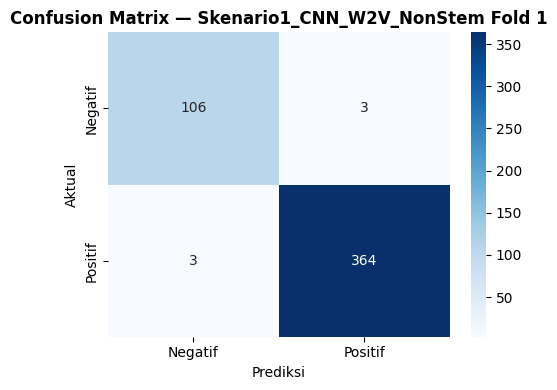

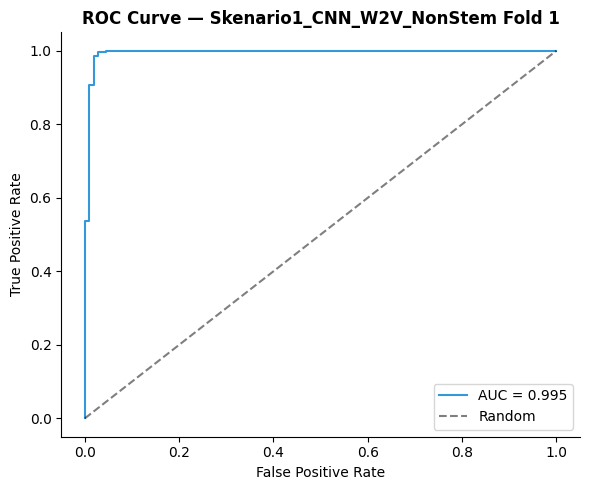


  ── Fold 2/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.7897 - auc: 0.7702 - loss: 0.8351 - val_accuracy: 0.9475 - val_auc: 0.9781 - val_loss: 0.5573
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.9132 - auc: 0.9543 - loss: 0.5733 - val_accuracy: 0.9727 - val_auc: 0.9864 - val_loss: 0.4360
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9469 - auc: 0.9796 - loss: 0.4594 - val_accuracy: 0.9748 - val_auc: 0.9884 - val_loss: 0.3870
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9611 - auc: 0.9906 - loss: 0.3798 - val_accuracy: 0.9790 - val_auc: 0.9904 - val_loss: 0.3410
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9727 - auc: 0.9916 - loss: 0.3380 - val_accuracy: 0.9748 - val_auc: 0.9907 - val_loss: 0.3107
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9742 - auc: 0.9934 - loss: 0.2992 - val_accuracy: 0.9790 - val_auc: 0.9908 - val_los

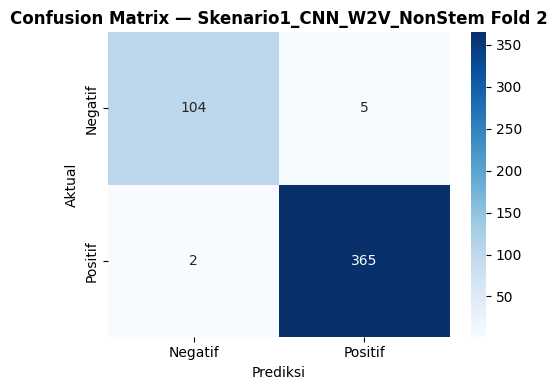

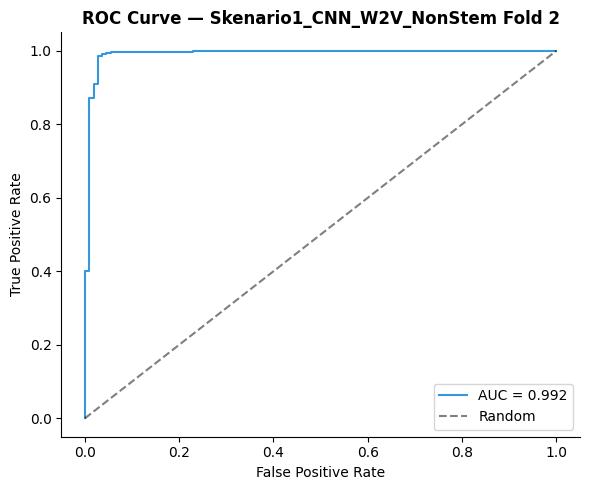


  ── Fold 3/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8176 - auc: 0.8167 - loss: 0.7956 - val_accuracy: 0.9391 - val_auc: 0.9812 - val_loss: 0.5434
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.9148 - auc: 0.9551 - loss: 0.5687 - val_accuracy: 0.9685 - val_auc: 0.9923 - val_loss: 0.4362
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9469 - auc: 0.9812 - loss: 0.4613 - val_accuracy: 0.9727 - val_auc: 0.9932 - val_loss: 0.3942
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9590 - auc: 0.9858 - loss: 0.4034 - val_accuracy: 0.9790 - val_auc: 0.9940 - val_loss: 0.3476
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9742 - auc: 0.9928 - loss: 0.3390 - val_accuracy: 0.9790 - val_auc: 0.9953 - val_loss: 0.3165
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9795 - auc: 0.9959 - loss: 0.2967 - val_accuracy: 0.9811 - val_auc: 0.9954 - val_los

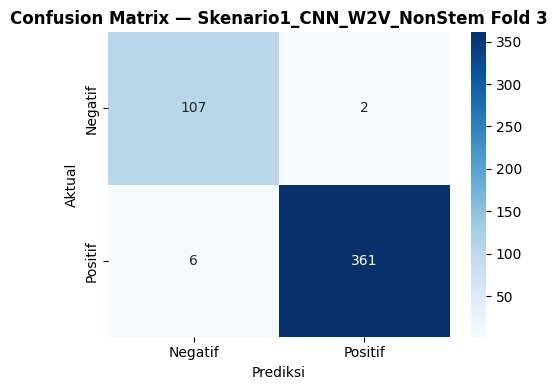

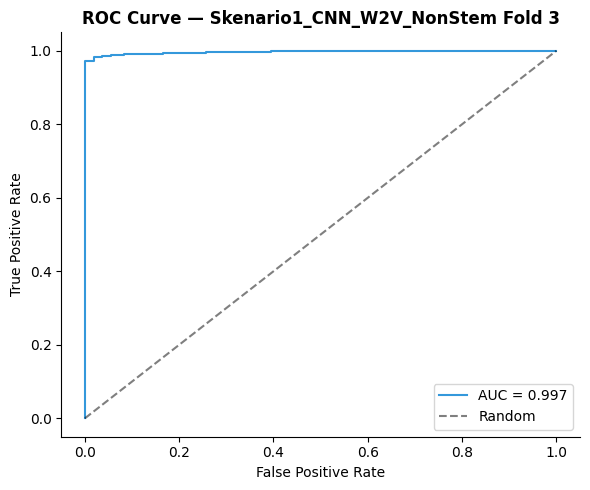


  ── Fold 4/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.8019 - auc: 0.7894 - loss: 0.8253 - val_accuracy: 0.9011 - val_auc: 0.9692 - val_loss: 0.6068
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9228 - auc: 0.9662 - loss: 0.5492 - val_accuracy: 0.9411 - val_auc: 0.9841 - val_loss: 0.4715
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9522 - auc: 0.9816 - loss: 0.4459 - val_accuracy: 0.9516 - val_auc: 0.9896 - val_loss: 0.4160
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9611 - auc: 0.9873 - loss: 0.3942 - val_accuracy: 0.9537 - val_auc: 0.9921 - val_loss: 0.3689
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9795 - auc: 0.9920 - loss: 0.3338 - val_accuracy: 0.9516 - val_auc: 0.9927 - val_loss: 0.3365
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.9743 - auc: 0.9901 - loss: 0.3061 - val_accuracy: 0.9558 - val_auc: 0.9935 - val_los

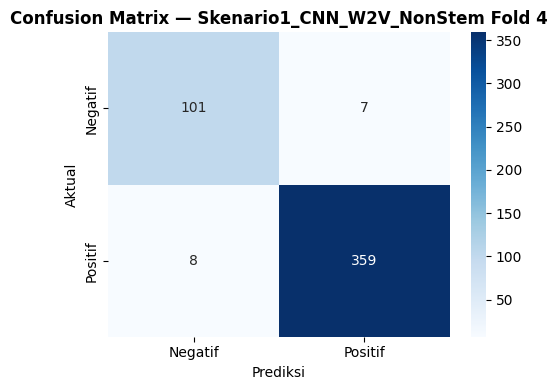

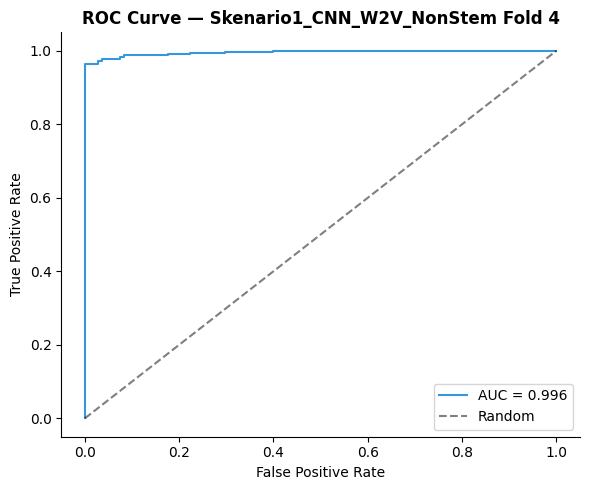


  ── Fold 5/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.7998 - auc: 0.7716 - loss: 0.8416 - val_accuracy: 0.9347 - val_auc: 0.9757 - val_loss: 0.5967
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9170 - auc: 0.9564 - loss: 0.5712 - val_accuracy: 0.9537 - val_auc: 0.9892 - val_loss: 0.4479
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9411 - auc: 0.9789 - loss: 0.4643 - val_accuracy: 0.9663 - val_auc: 0.9916 - val_loss: 0.4097
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9548 - auc: 0.9848 - loss: 0.4115 - val_accuracy: 0.9705 - val_auc: 0.9942 - val_loss: 0.3620
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9700 - auc: 0.9867 - loss: 0.3624 - val_accuracy: 0.9747 - val_auc: 0.9943 - val_loss: 0.3288
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9779 - auc: 0.9940 - loss: 0.3106 - val_accuracy: 0.9747 - val_auc: 0.9947 - val_los

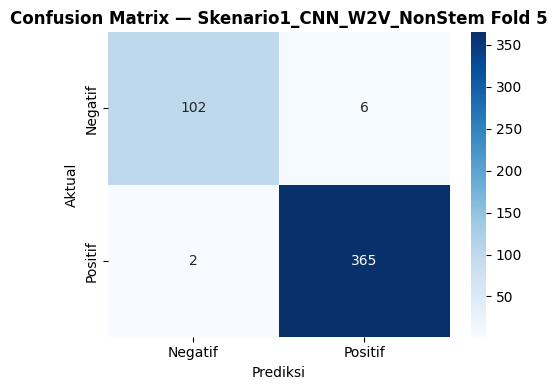

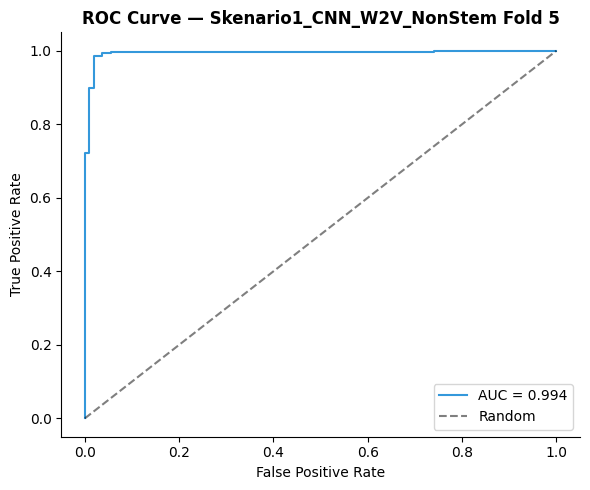


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario1_CNN_W2V_NonStem/model.h5


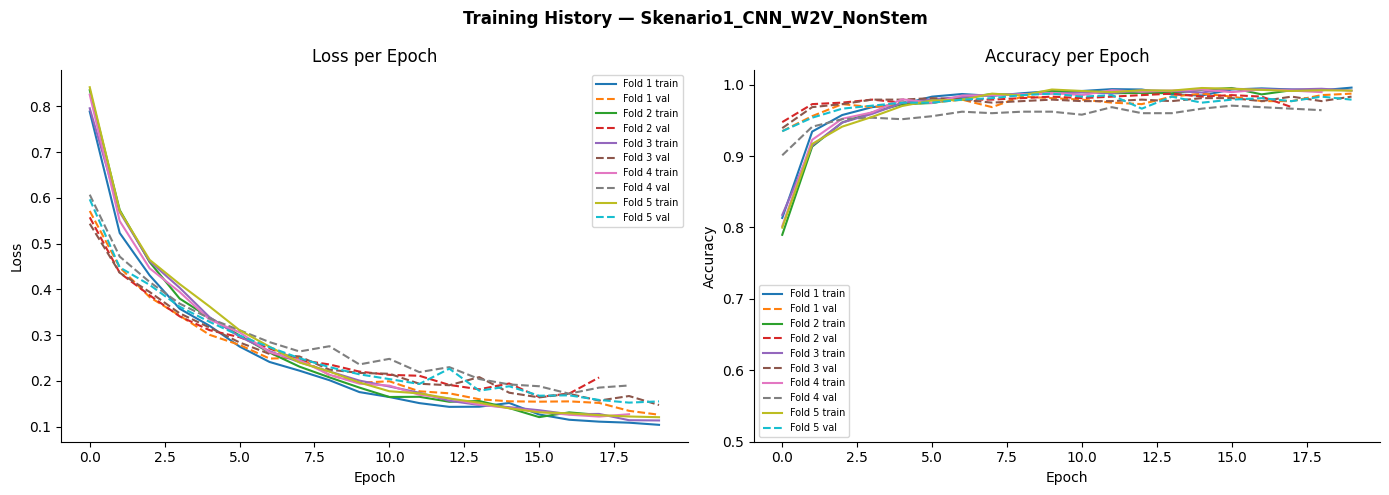


  ╔═ SELESAI: Skenario1_CNN_W2V_NonStem
  ║  avg Precision  : 0.9745 ± 0.0128
  ║  avg Recall     : 0.9731 ± 0.0107
  ║  avg F1 Macro   : 0.9737 ± 0.0106
  ║  avg Accuracy   : 0.9815 ± 0.0075
  ║  avg AUC        : 0.9947 ± 0.0020
  ║  avg RAM        : 2582.9 MB (19.9%)
  ║  avg CPU        : 6.0 %
  ║  avg Waktu      : 84.67 detik/fold
  ║  avg T/Epoch    : 4.34 detik/epoch
  ║  avg T/Step     : 0.0735 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 1 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[0])


  Training: Skenario2_CNN_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.7886 - auc: 0.7568 - loss: 0.8542 - val_accuracy: 0.9181 - val_auc: 0.9604 - val_loss: 0.6066
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.9154 - auc: 0.9486 - loss: 0.5802 - val_accuracy: 0.9454 - val_auc: 0.9811 - val_loss: 0.4811
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9485 - auc: 0.9778 - loss: 0.4663 - val_accuracy: 0.9496 - val_auc: 0.9867 - val_loss: 0.4176
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9558 - auc: 0.9883 - loss: 0.3946 - val_accuracy: 0.9622 - val_auc: 0.9866 - val_loss: 0.3715
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9706 - auc: 0.9923 - loss: 0.3417 - val_accuracy: 0.96

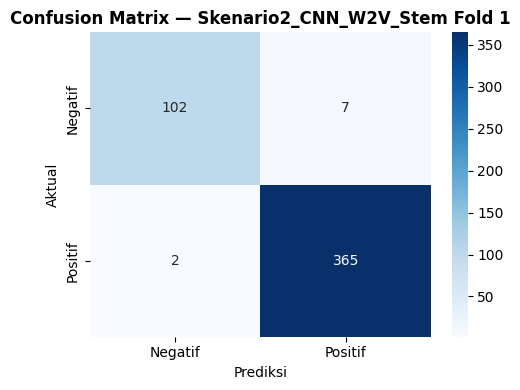

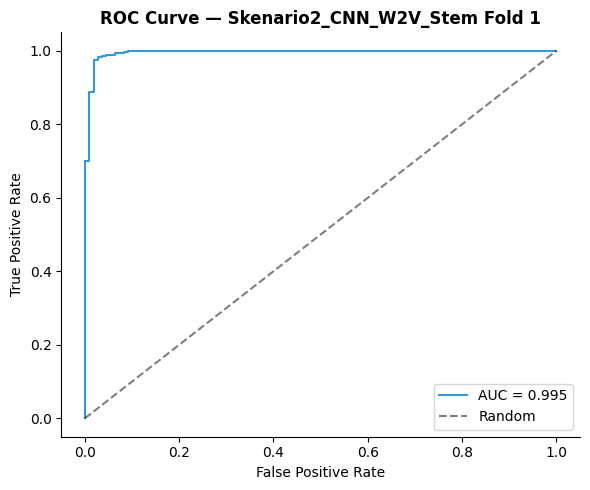


  ── Fold 2/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.8244 - auc: 0.8036 - loss: 0.8070 - val_accuracy: 0.9517 - val_auc: 0.9778 - val_loss: 0.5539
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9033 - auc: 0.9573 - loss: 0.5758 - val_accuracy: 0.9664 - val_auc: 0.9841 - val_loss: 0.4562
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9474 - auc: 0.9828 - loss: 0.4635 - val_accuracy: 0.9769 - val_auc: 0.9849 - val_loss: 0.4003
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9627 - auc: 0.9861 - loss: 0.4052 - val_accuracy: 0.9790 - val_auc: 0.9857 - val_loss: 0.3575
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9679 - auc: 0.9913 - loss: 0.3520 - val_accuracy: 0.9811 - val_auc: 0.9866 - val_loss: 0.3310
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9742 - auc: 0.9943 - loss: 0.3072 - val_accuracy: 0.9769 - val_auc: 0.9873 - val_los

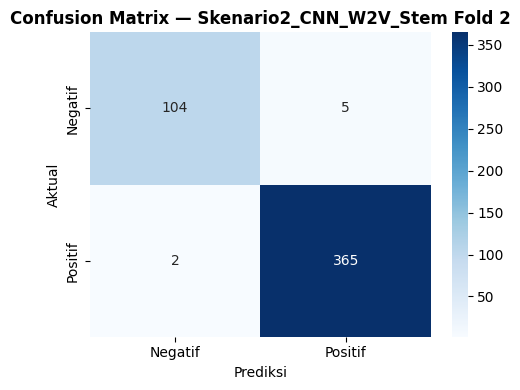

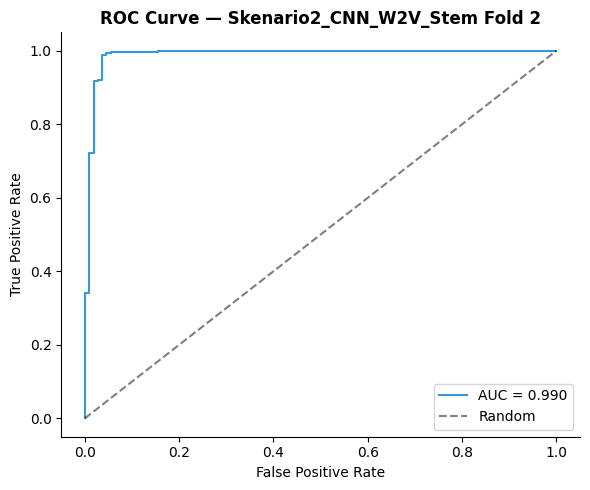


  ── Fold 3/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.7955 - auc: 0.7836 - loss: 0.8302 - val_accuracy: 0.9433 - val_auc: 0.9788 - val_loss: 0.5811
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9159 - auc: 0.9508 - loss: 0.5779 - val_accuracy: 0.9664 - val_auc: 0.9923 - val_loss: 0.4507
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9479 - auc: 0.9799 - loss: 0.4613 - val_accuracy: 0.9664 - val_auc: 0.9939 - val_loss: 0.3938
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9642 - auc: 0.9875 - loss: 0.3927 - val_accuracy: 0.9727 - val_auc: 0.9947 - val_loss: 0.3381
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9716 - auc: 0.9911 - loss: 0.3437 - val_accuracy: 0.9748 - val_auc: 0.9963 - val_loss: 0.3119
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9826 - auc: 0.9960 - loss: 0.2878 - val_accuracy: 0.9811 - val_auc: 0.9957 - val_los

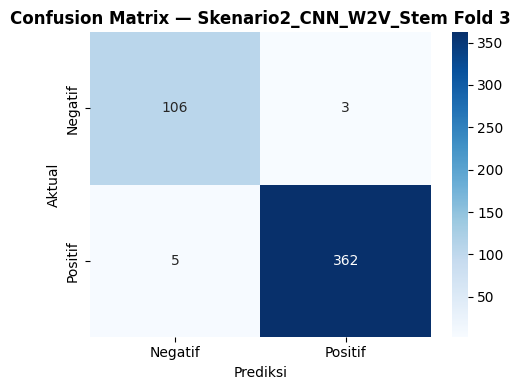

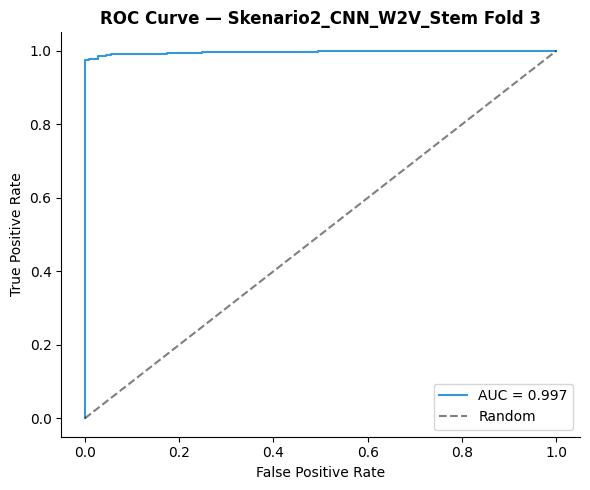


  ── Fold 4/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.7914 - auc: 0.7535 - loss: 0.8483 - val_accuracy: 0.8800 - val_auc: 0.9612 - val_loss: 0.6413
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9101 - auc: 0.9540 - loss: 0.5663 - val_accuracy: 0.9347 - val_auc: 0.9793 - val_loss: 0.4859
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9490 - auc: 0.9771 - loss: 0.4532 - val_accuracy: 0.9432 - val_auc: 0.9844 - val_loss: 0.4199
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9569 - auc: 0.9843 - loss: 0.3847 - val_accuracy: 0.9516 - val_auc: 0.9895 - val_loss: 0.3636
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9669 - auc: 0.9896 - loss: 0.3339 - val_accuracy: 0.9579 - val_auc: 0.9924 - val_loss: 0.3238
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9737 - auc: 0.9922 - loss: 0.2930 - val_accuracy: 0.9600 - val_auc: 0.9931 - val_lo

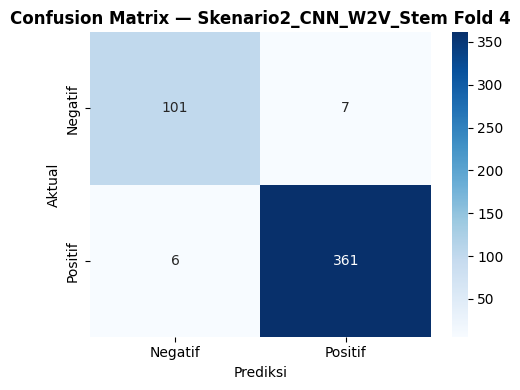

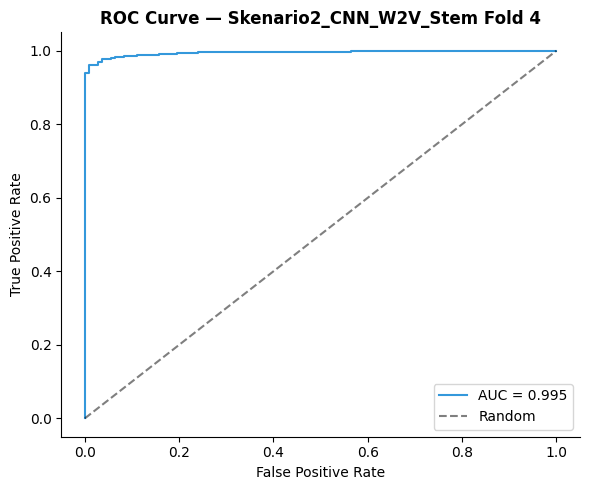


  ── Fold 5/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8297 - auc: 0.8145 - loss: 0.7979 - val_accuracy: 0.9284 - val_auc: 0.9759 - val_loss: 0.5660
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9175 - auc: 0.9511 - loss: 0.5719 - val_accuracy: 0.9516 - val_auc: 0.9876 - val_loss: 0.4579
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9464 - auc: 0.9763 - loss: 0.4683 - val_accuracy: 0.9537 - val_auc: 0.9906 - val_loss: 0.4118
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9564 - auc: 0.9844 - loss: 0.4095 - val_accuracy: 0.9621 - val_auc: 0.9918 - val_loss: 0.3578
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9732 - auc: 0.9902 - loss: 0.3434 - val_accuracy: 0.9747 - val_auc: 0.9926 - val_loss: 0.3244
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9806 - auc: 0.9938 - loss: 0.2997 - val_accuracy: 0.9747 - val_auc: 0.9934 - val_los

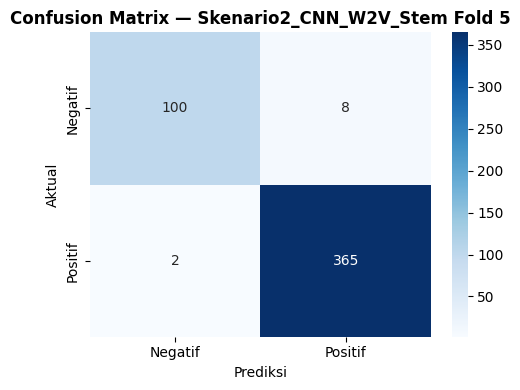

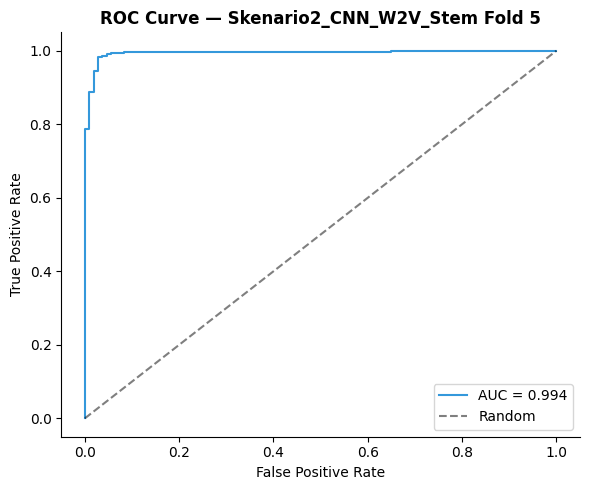


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario2_CNN_W2V_Stem/model.h5


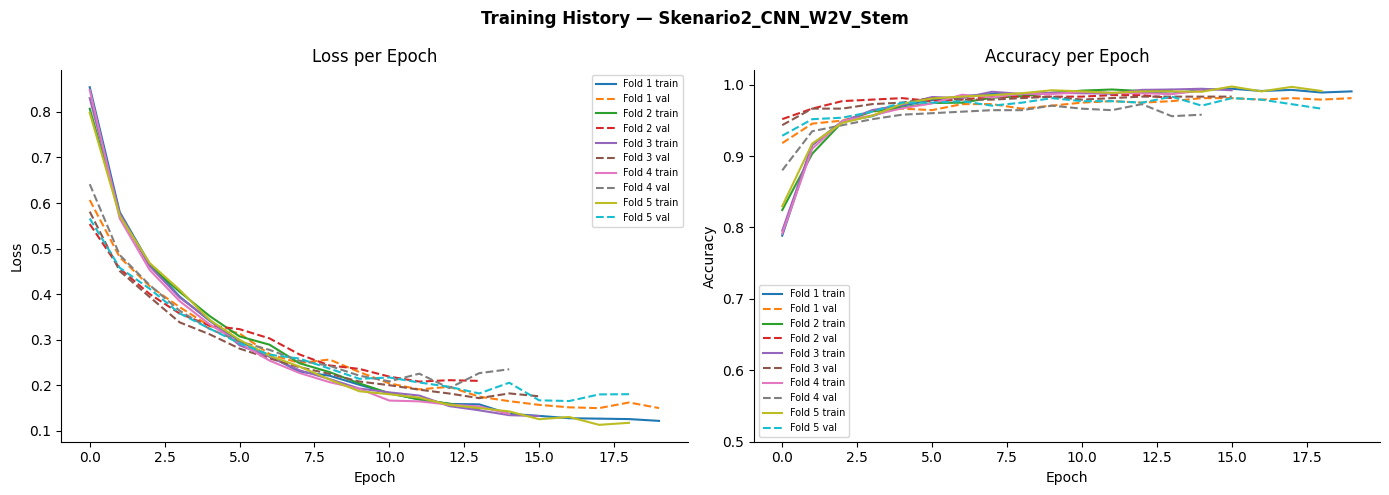


  ╔═ SELESAI: Skenario2_CNN_W2V_Stem
  ║  avg Precision  : 0.9760 ± 0.0085
  ║  avg Recall     : 0.9677 ± 0.0088
  ║  avg F1 Macro   : 0.9717 ± 0.0070
  ║  avg Accuracy   : 0.9802 ± 0.0049
  ║  avg AUC        : 0.9943 ± 0.0028
  ║  avg RAM        : 2715.7 MB (20.9%)
  ║  avg CPU        : 15.8 %
  ║  avg Waktu      : 69.16 detik/fold
  ║  avg T/Epoch    : 4.08 detik/epoch
  ║  avg T/Step     : 0.0692 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 2 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[1])


  Training: Skenario3_CNN_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7808 - auc: 0.7733 - loss: 0.8388 - val_accuracy: 0.9391 - val_auc: 0.9564 - val_loss: 0.6271
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8985 - auc: 0.9413 - loss: 0.5993 - val_accuracy: 0.9496 - val_auc: 0.9802 - val_loss: 0.4892
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9374 - auc: 0.9717 - loss: 0.4775 - val_accuracy: 0.9538 - val_auc: 0.9855 - val_loss: 0.4202
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9558 - auc: 0.9851 - loss: 0.3951 - val_accuracy: 0.9622 - val_auc: 0.9892 - val_loss: 0.3565
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9632 - auc: 0.9899 - loss: 0.3488 - val_accuracy: 0.9622

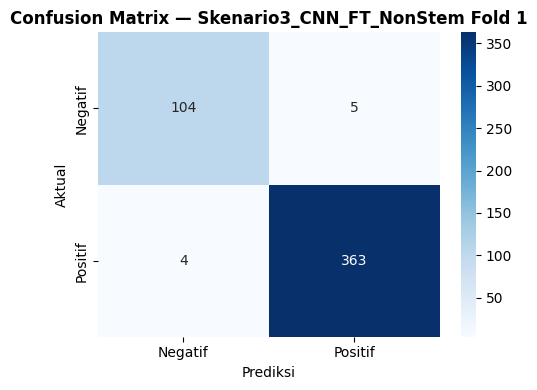

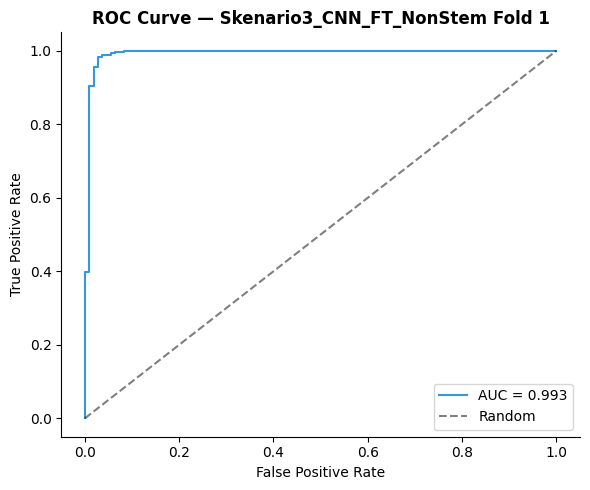


  ── Fold 2/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.7960 - auc: 0.7762 - loss: 0.8328 - val_accuracy: 0.9307 - val_auc: 0.9744 - val_loss: 0.6155
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9069 - auc: 0.9453 - loss: 0.5909 - val_accuracy: 0.9748 - val_auc: 0.9848 - val_loss: 0.4419
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9401 - auc: 0.9764 - loss: 0.4705 - val_accuracy: 0.9559 - val_auc: 0.9876 - val_loss: 0.4098
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9569 - auc: 0.9856 - loss: 0.4054 - val_accuracy: 0.9769 - val_auc: 0.9903 - val_loss: 0.3477
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9690 - auc: 0.9867 - loss: 0.3566 - val_accuracy: 0.9790 - val_auc: 0.9909 - val_loss: 0.3217
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9711 - auc: 0.9935 - loss: 0.3109 - val_accuracy: 0.9769 - val_auc: 0.9911 - val_los

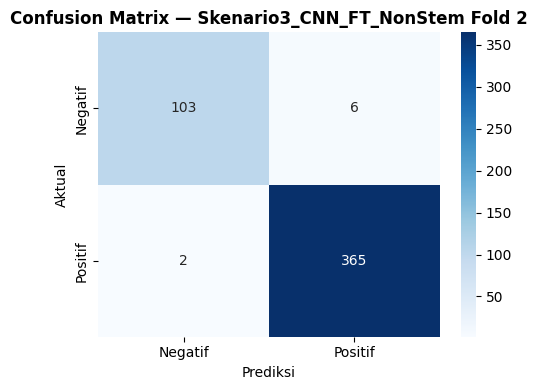

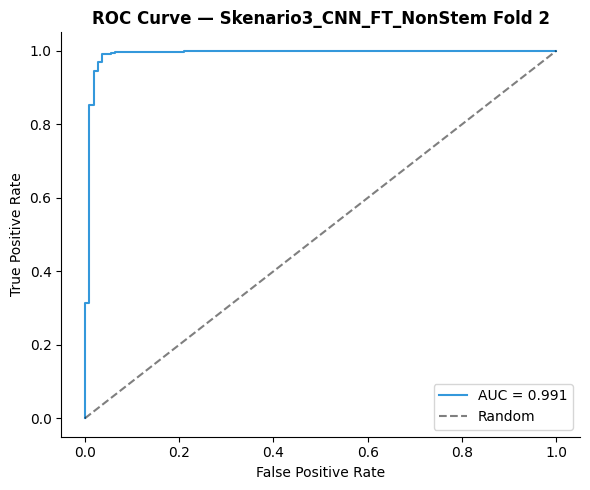


  ── Fold 3/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.7813 - auc: 0.7374 - loss: 0.8709 - val_accuracy: 0.9307 - val_auc: 0.9745 - val_loss: 0.6170
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9033 - auc: 0.9438 - loss: 0.5978 - val_accuracy: 0.9685 - val_auc: 0.9915 - val_loss: 0.4525
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9437 - auc: 0.9732 - loss: 0.4814 - val_accuracy: 0.9559 - val_auc: 0.9939 - val_loss: 0.4057
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9590 - auc: 0.9874 - loss: 0.3997 - val_accuracy: 0.9706 - val_auc: 0.9949 - val_loss: 0.3464
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9716 - auc: 0.9908 - loss: 0.3480 - val_accuracy: 0.9769 - val_auc: 0.9956 - val_loss: 0.3070
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9774 - auc: 0.9928 - loss: 0.3047 - val_accuracy: 0.9769 - val_auc: 0.9961 - val_los

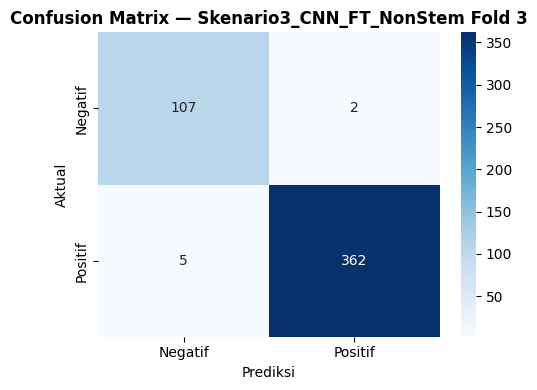

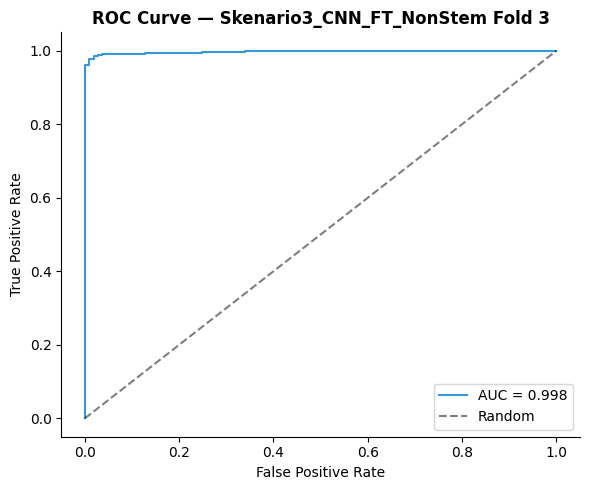


  ── Fold 4/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.8061 - auc: 0.7685 - loss: 0.8311 - val_accuracy: 0.9011 - val_auc: 0.9549 - val_loss: 0.6121
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9096 - auc: 0.9496 - loss: 0.5699 - val_accuracy: 0.9347 - val_auc: 0.9749 - val_loss: 0.4869
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9406 - auc: 0.9781 - loss: 0.4562 - val_accuracy: 0.9453 - val_auc: 0.9829 - val_loss: 0.4224
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9664 - auc: 0.9881 - loss: 0.3739 - val_accuracy: 0.9537 - val_auc: 0.9860 - val_loss: 0.3820
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.9674 - auc: 0.9889 - loss: 0.3405 - val_accuracy: 0.9516 - val_auc: 0.9883 - val_loss: 0.3578
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9711 - auc: 0.9904 - loss: 0.3019 - val_accuracy: 0.9621 - val_auc: 0.9922 - val_los

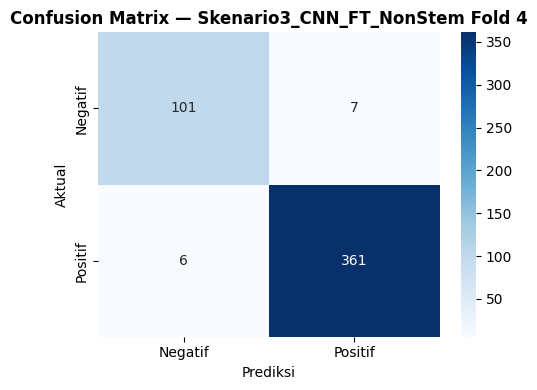

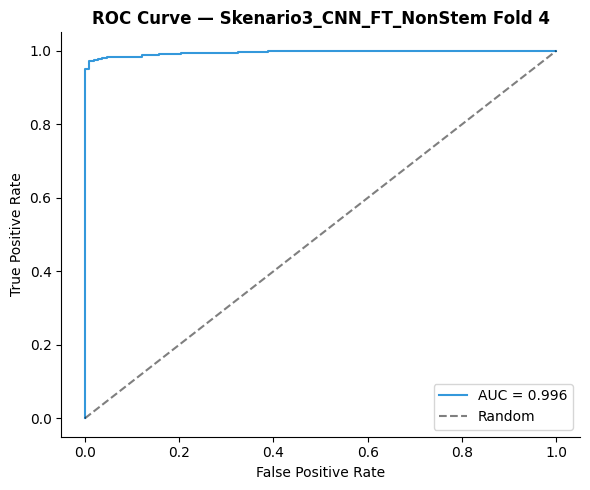


  ── Fold 5/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.7846 - auc: 0.7590 - loss: 0.8535 - val_accuracy: 0.9326 - val_auc: 0.9715 - val_loss: 0.6181
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8939 - auc: 0.9368 - loss: 0.6091 - val_accuracy: 0.9558 - val_auc: 0.9850 - val_loss: 0.4730
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9317 - auc: 0.9693 - loss: 0.4890 - val_accuracy: 0.9579 - val_auc: 0.9910 - val_loss: 0.4107
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9496 - auc: 0.9874 - loss: 0.4008 - val_accuracy: 0.9684 - val_auc: 0.9931 - val_loss: 0.3522
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9606 - auc: 0.9865 - loss: 0.3710 - val_accuracy: 0.9684 - val_auc: 0.9935 - val_loss: 0.3292
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9748 - auc: 0.9910 - loss: 0.3156 - val_accuracy: 0.9726 - val_auc: 0.9936 - val_los

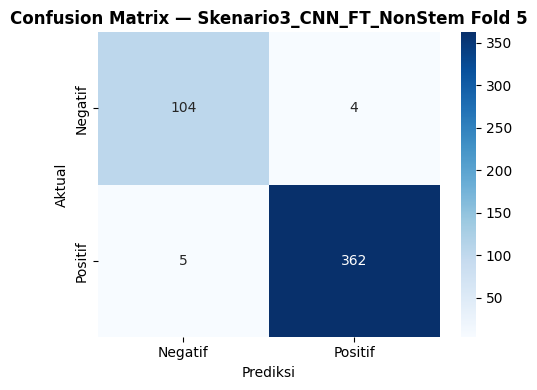

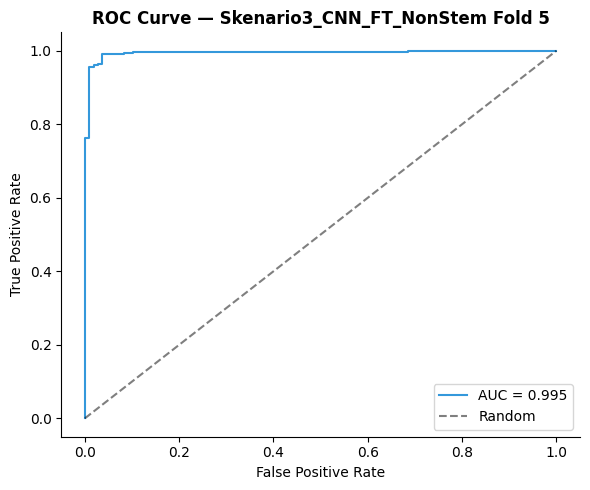


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario3_CNN_FT_NonStem/model.h5


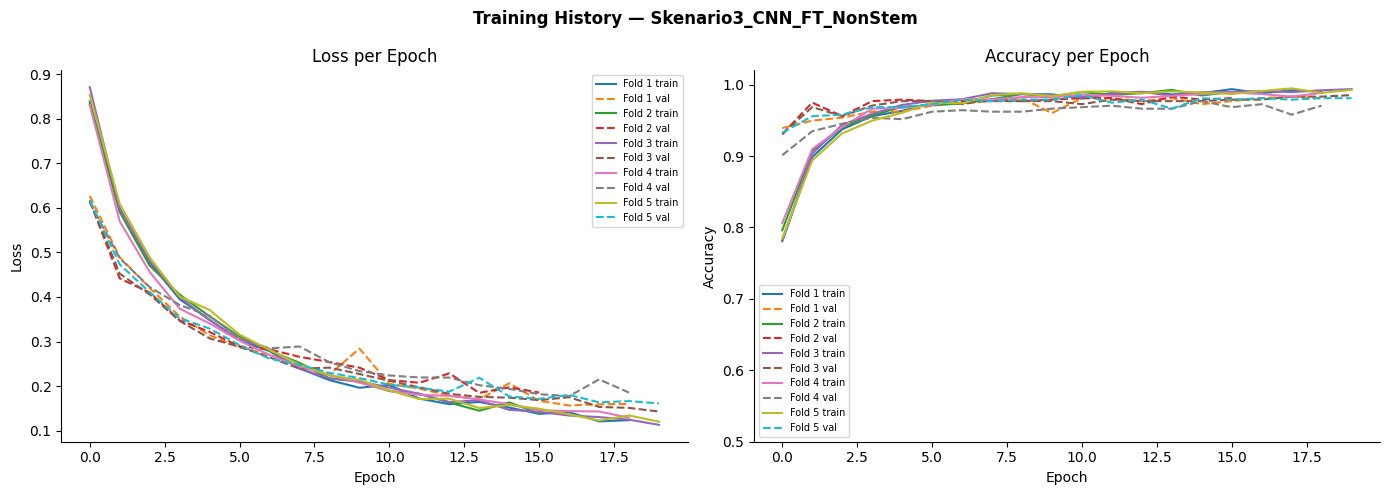


  ╔═ SELESAI: Skenario3_CNN_FT_NonStem
  ║  avg Precision  : 0.9732 ± 0.0072
  ║  avg Recall     : 0.9719 ± 0.0089
  ║  avg F1 Macro   : 0.9725 ± 0.0070
  ║  avg Accuracy   : 0.9807 ± 0.0048
  ║  avg AUC        : 0.9944 ± 0.0026
  ║  avg RAM        : 2790.1 MB (21.5%)
  ║  avg CPU        : 33.5 %
  ║  avg Waktu      : 81.13 detik/fold
  ║  avg T/Epoch    : 4.31 detik/epoch
  ║  avg T/Step     : 0.0730 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 3 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[2])


  Training: Skenario4_CNN_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.8149 - auc: 0.7952 - loss: 0.8116 - val_accuracy: 0.9202 - val_auc: 0.9578 - val_loss: 0.5966
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.9017 - auc: 0.9493 - loss: 0.5793 - val_accuracy: 0.9370 - val_auc: 0.9767 - val_loss: 0.4842
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9432 - auc: 0.9773 - loss: 0.4620 - val_accuracy: 0.9412 - val_auc: 0.9836 - val_loss: 0.4241
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9595 - auc: 0.9842 - loss: 0.3978 - val_accuracy: 0.9580 - val_auc: 0.9860 - val_loss: 0.3693
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9679 - auc: 0.9916 - loss: 0.3380 - val_accuracy: 0.9643 - 

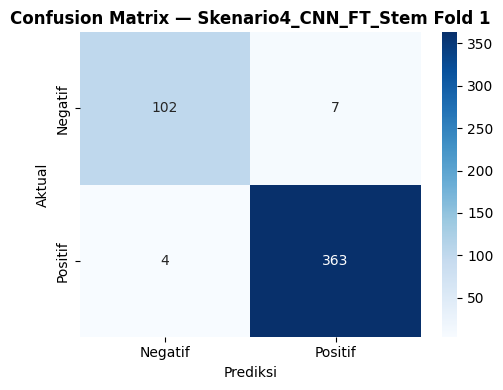

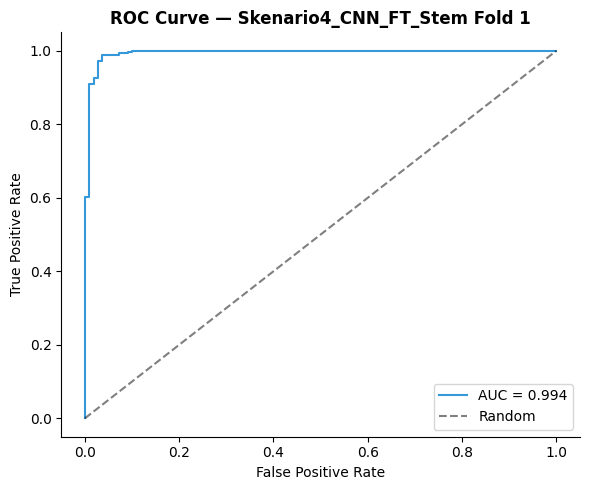


  ── Fold 2/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.7844 - auc: 0.7094 - loss: 0.8760 - val_accuracy: 0.9118 - val_auc: 0.9717 - val_loss: 0.6198
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8917 - auc: 0.9296 - loss: 0.6188 - val_accuracy: 0.9664 - val_auc: 0.9843 - val_loss: 0.4587
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9380 - auc: 0.9747 - loss: 0.4715 - val_accuracy: 0.9706 - val_auc: 0.9873 - val_loss: 0.3816
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9527 - auc: 0.9864 - loss: 0.3868 - val_accuracy: 0.9769 - val_auc: 0.9888 - val_loss: 0.3379
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9595 - auc: 0.9870 - loss: 0.3517 - val_accuracy: 0.9790 - val_auc: 0.9900 - val_loss: 0.3073
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9758 - auc: 0.9911 - loss: 0.2997 - val_accuracy: 0.9769 - val_auc: 0.9906 - val_los

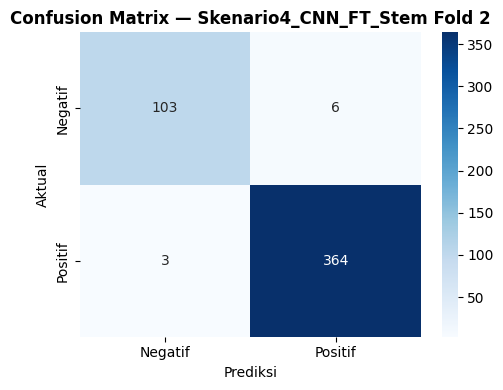

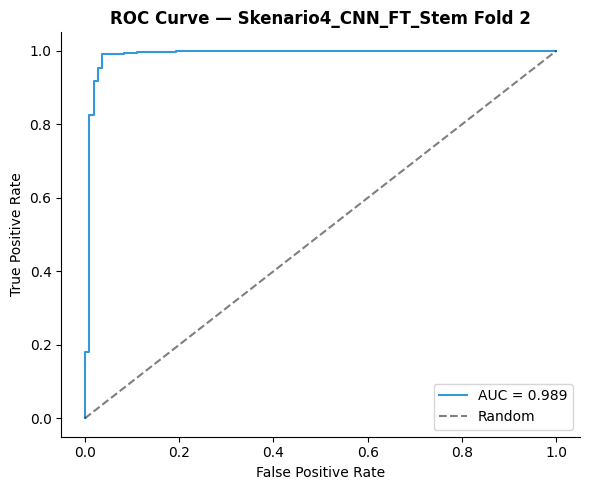


  ── Fold 3/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7960 - auc: 0.7370 - loss: 0.8550 - val_accuracy: 0.9244 - val_auc: 0.9777 - val_loss: 0.5921
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.8980 - auc: 0.9472 - loss: 0.5857 - val_accuracy: 0.9559 - val_auc: 0.9914 - val_loss: 0.4589
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9317 - auc: 0.9720 - loss: 0.4798 - val_accuracy: 0.9559 - val_auc: 0.9937 - val_loss: 0.4128
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9527 - auc: 0.9805 - loss: 0.4103 - val_accuracy: 0.9559 - val_auc: 0.9946 - val_loss: 0.3818
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9658 - auc: 0.9891 - loss: 0.3511 - val_accuracy: 0.9643 - val_auc: 0.9951 - val_loss: 0.3194
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9664 - auc: 0.9920 - loss: 0.3109 - val_accuracy: 0.9769 - val_auc: 0.9952 - val_los

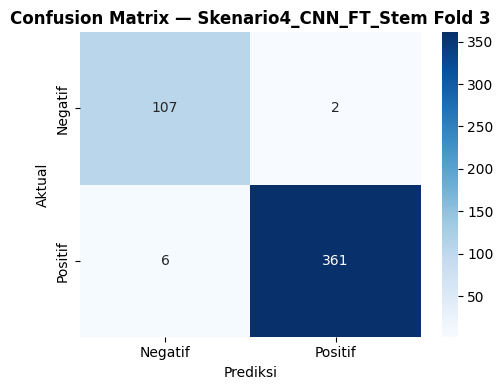

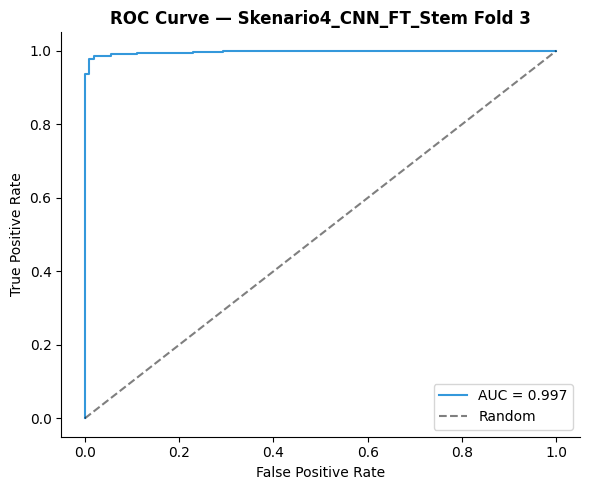


  ── Fold 4/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.7951 - auc: 0.7819 - loss: 0.8262 - val_accuracy: 0.9095 - val_auc: 0.9617 - val_loss: 0.6033
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9185 - auc: 0.9549 - loss: 0.5617 - val_accuracy: 0.9305 - val_auc: 0.9764 - val_loss: 0.4823
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9380 - auc: 0.9746 - loss: 0.4664 - val_accuracy: 0.9411 - val_auc: 0.9841 - val_loss: 0.4232
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9601 - auc: 0.9839 - loss: 0.3917 - val_accuracy: 0.9495 - val_auc: 0.9882 - val_loss: 0.3776
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9711 - auc: 0.9897 - loss: 0.3350 - val_accuracy: 0.9600 - val_auc: 0.9903 - val_loss: 0.3347
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9748 - auc: 0.9901 - loss: 0.3022 - val_accuracy: 0.9663 - val_auc: 0.9924 - val_los

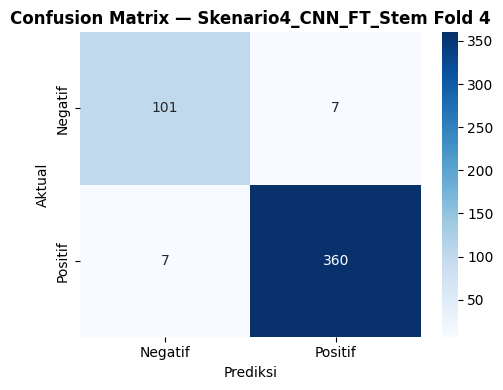

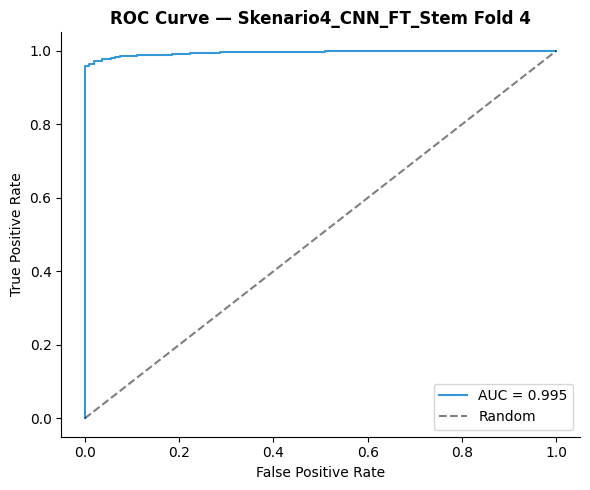


  ── Fold 5/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.7877 - auc: 0.7347 - loss: 0.8650 - val_accuracy: 0.8926 - val_auc: 0.9637 - val_loss: 0.6348
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.8886 - auc: 0.9369 - loss: 0.6053 - val_accuracy: 0.9474 - val_auc: 0.9839 - val_loss: 0.4866
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9343 - auc: 0.9727 - loss: 0.4836 - val_accuracy: 0.9579 - val_auc: 0.9887 - val_loss: 0.4105
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9543 - auc: 0.9812 - loss: 0.4102 - val_accuracy: 0.9558 - val_auc: 0.9917 - val_loss: 0.3617
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9690 - auc: 0.9870 - loss: 0.3541 - val_accuracy: 0.9621 - val_auc: 0.9921 - val_loss: 0.3249
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.9785 - auc: 0.9911 - loss: 0.3053 - val_accuracy: 0.9663 - val_auc: 0.9923 - val_los

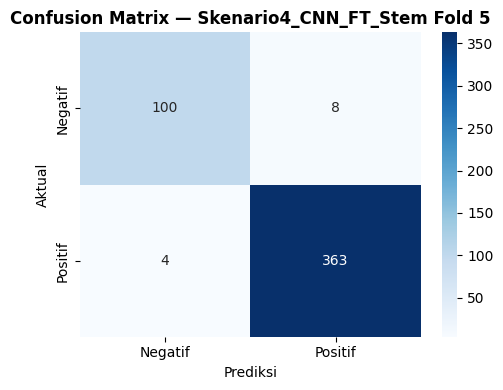

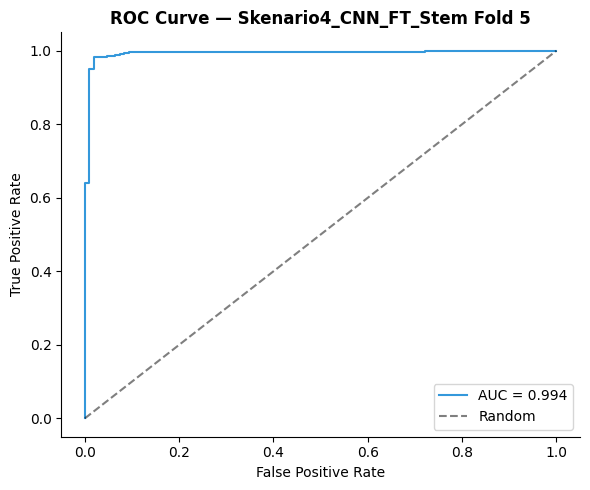


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario4_CNN_FT_Stem/model.h5


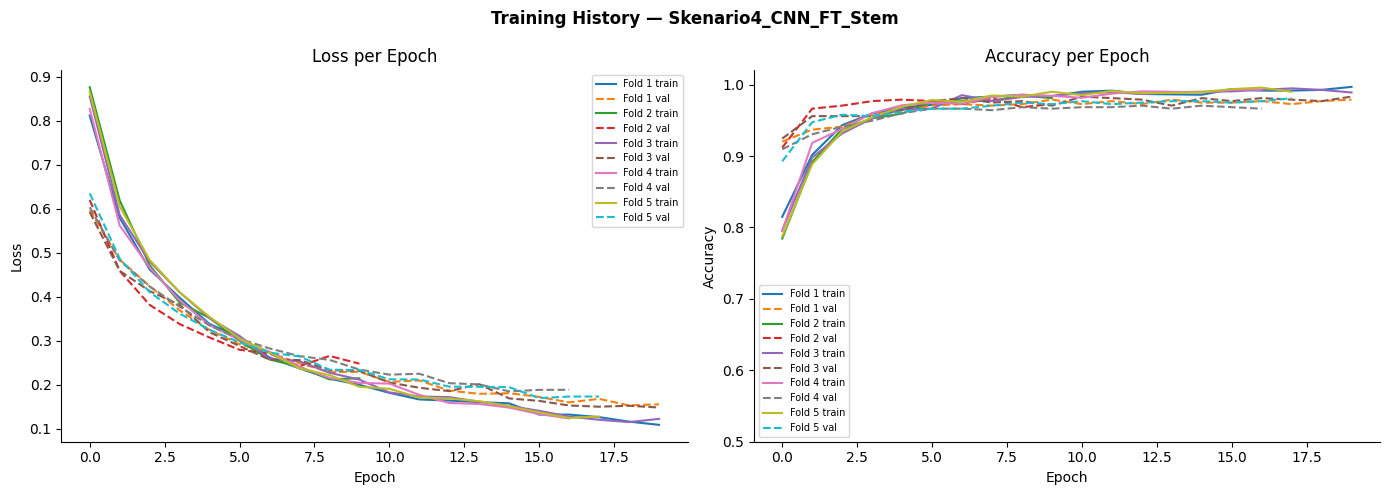


  ╔═ SELESAI: Skenario4_CNN_FT_Stem
  ║  avg Precision  : 0.9696 ± 0.0072
  ║  avg Recall     : 0.9658 ± 0.0104
  ║  avg F1 Macro   : 0.9676 ± 0.0073
  ║  avg Accuracy   : 0.9773 ± 0.0050
  ║  avg AUC        : 0.9939 ± 0.0032
  ║  avg RAM        : 2909.3 MB (22.4%)
  ║  avg CPU        : 26.1 %
  ║  avg Waktu      : 71.46 detik/fold
  ║  avg T/Epoch    : 4.23 detik/epoch
  ║  avg T/Step     : 0.0717 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 4 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[3])


  Training: Skenario5_BiLSTM_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.7965 - auc: 0.7726 - loss: 0.5189 - val_accuracy: 0.8634 - val_auc: 0.9417 - val_loss: 0.3761
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - accuracy: 0.8970 - auc: 0.9217 - loss: 0.3332 - val_accuracy: 0.9160 - val_auc: 0.9603 - val_loss: 0.2607
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/step - accuracy: 0.9143 - auc: 0.9465 - loss: 0.2682 - val_accuracy: 0.9433 - val_auc: 0.9685 - val_loss: 0.2029
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 228ms/step - accuracy: 0.9285 - auc: 0.9633 - loss: 0.2283 - val_accuracy: 0.9580 - val_auc: 0.9736 - val_loss: 0.1824
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.9390 - auc: 0.9720 - loss: 0.1941 - va

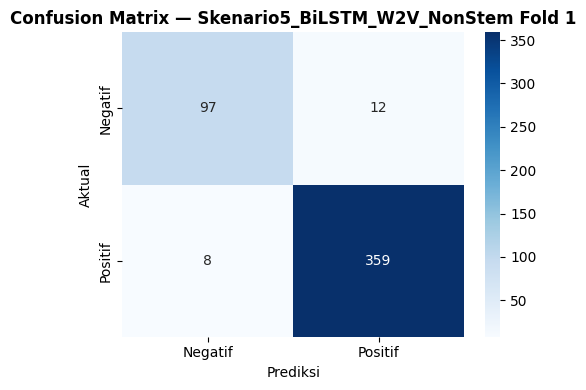

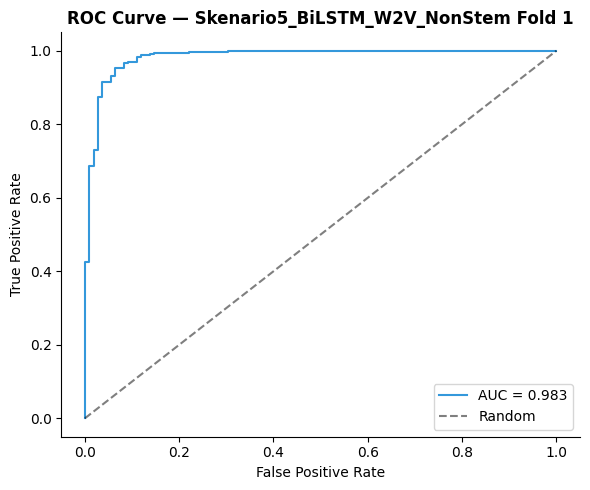


  ── Fold 2/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.8002 - auc: 0.7640 - loss: 0.5219 - val_accuracy: 0.9412 - val_auc: 0.9604 - val_loss: 0.2805
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.8891 - auc: 0.9359 - loss: 0.3122 - val_accuracy: 0.9517 - val_auc: 0.9670 - val_loss: 0.2235
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.9185 - auc: 0.9460 - loss: 0.2708 - val_accuracy: 0.9559 - val_auc: 0.9663 - val_loss: 0.2001
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.9238 - auc: 0.9621 - loss: 0.2312 - val_accuracy: 0.9517 - val_auc: 0.9782 - val_loss: 0.1723
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 252ms/step - accuracy: 0.9338 - auc: 0.9675 - loss: 0.2098 - val_accuracy: 0.9727 - val_auc: 0.9837 - val_loss: 0.1357
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 243ms/step - accuracy: 0.9359 - auc: 0.9754 - loss: 0.1904 - val_accuracy: 0.9727 - val_auc: 0.98

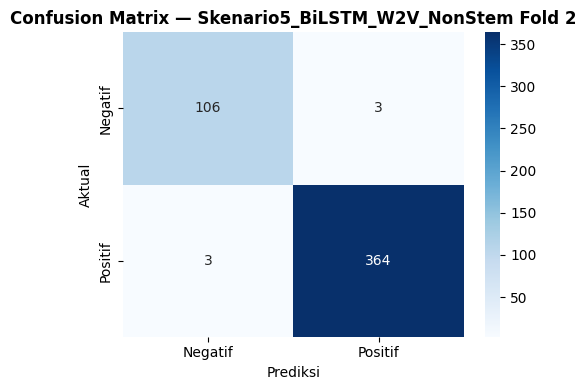

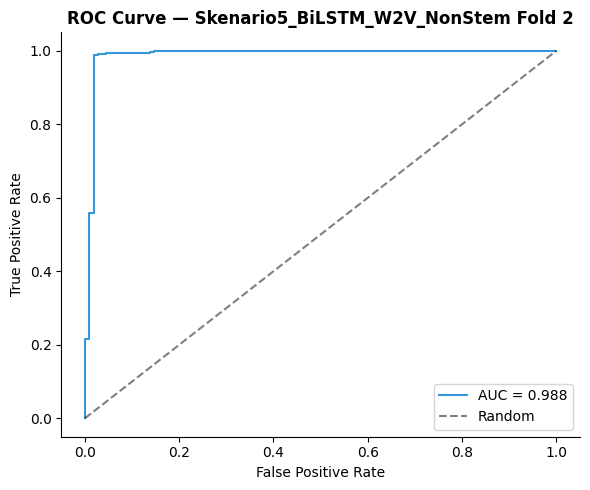


  ── Fold 3/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 326ms/step - accuracy: 0.7992 - auc: 0.7766 - loss: 0.5146 - val_accuracy: 0.9265 - val_auc: 0.9624 - val_loss: 0.2846
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 233ms/step - accuracy: 0.8985 - auc: 0.9347 - loss: 0.3112 - val_accuracy: 0.9370 - val_auc: 0.9778 - val_loss: 0.2071
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 245ms/step - accuracy: 0.9175 - auc: 0.9481 - loss: 0.2657 - val_accuracy: 0.9454 - val_auc: 0.9813 - val_loss: 0.1782
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 248ms/step - accuracy: 0.9238 - auc: 0.9576 - loss: 0.2443 - val_accuracy: 0.9559 - val_auc: 0.9861 - val_loss: 0.1593
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - accuracy: 0.9332 - auc: 0.9675 - loss: 0.2095 - val_accuracy: 0.9538 - val_auc: 0.9874 - val_loss: 0.1539
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 239ms/step - accuracy: 0.9380 - auc: 0.9677 - loss: 0.2022 - val_accuracy: 0.9538 - val_auc: 0.98

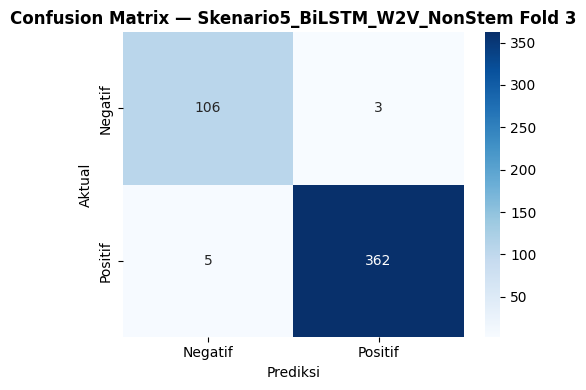

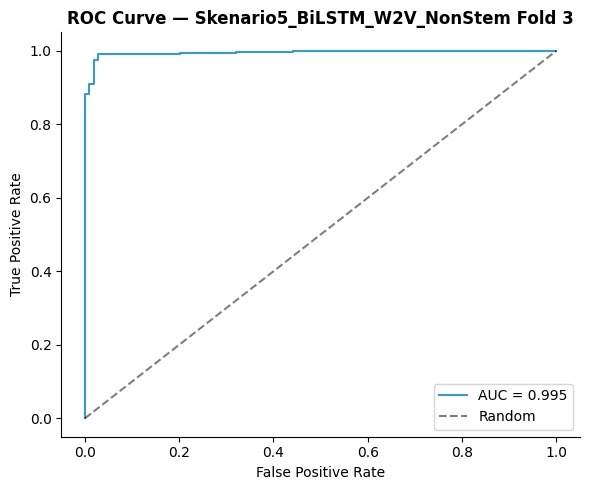


  ── Fold 4/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 259ms/step - accuracy: 0.7719 - auc: 0.7111 - loss: 0.5539 - val_accuracy: 0.8737 - val_auc: 0.9194 - val_loss: 0.3949
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 238ms/step - accuracy: 0.8944 - auc: 0.9145 - loss: 0.3528 - val_accuracy: 0.9053 - val_auc: 0.9546 - val_loss: 0.2756
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.9122 - auc: 0.9473 - loss: 0.2708 - val_accuracy: 0.9221 - val_auc: 0.9667 - val_loss: 0.2386
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.9285 - auc: 0.9589 - loss: 0.2374 - val_accuracy: 0.9242 - val_auc: 0.9685 - val_loss: 0.2260
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.9338 - auc: 0.9671 - loss: 0.2091 - val_accuracy: 0.9305 - val_auc: 0.9733 - val_loss: 0.2033
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.9427 - auc: 0.9705 - loss: 0.1984 - val_accuracy: 0.9368 - val_auc: 0.97

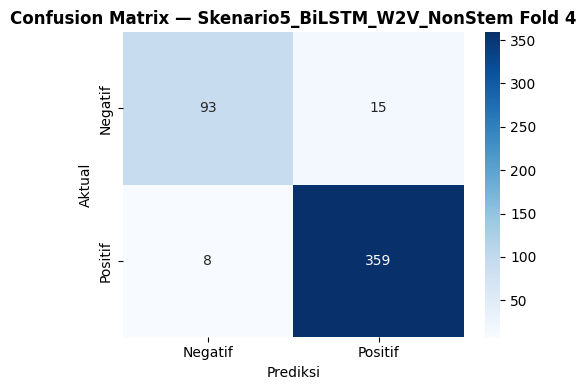

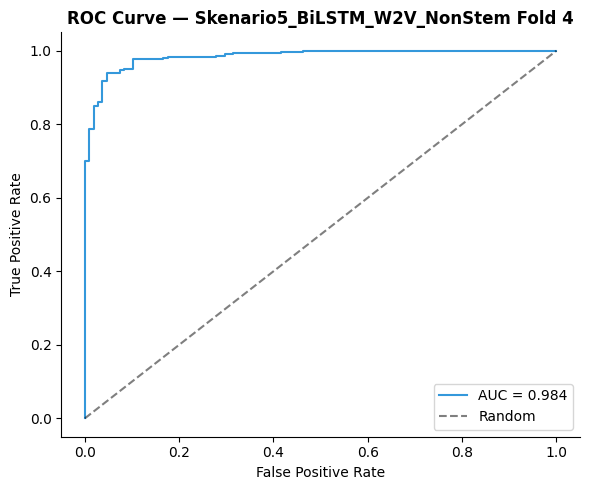


  ── Fold 5/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 268ms/step - accuracy: 0.7830 - auc: 0.7178 - loss: 0.5538 - val_accuracy: 0.8926 - val_auc: 0.9319 - val_loss: 0.3518
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 248ms/step - accuracy: 0.8891 - auc: 0.9134 - loss: 0.3436 - val_accuracy: 0.8800 - val_auc: 0.9575 - val_loss: 0.3044
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 248ms/step - accuracy: 0.9107 - auc: 0.9423 - loss: 0.2751 - val_accuracy: 0.9326 - val_auc: 0.9736 - val_loss: 0.2083
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - accuracy: 0.9270 - auc: 0.9553 - loss: 0.2381 - val_accuracy: 0.9432 - val_auc: 0.9821 - val_loss: 0.1787
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 248ms/step - accuracy: 0.9296 - auc: 0.9590 - loss: 0.2225 - val_accuracy: 0.9347 - val_auc: 0.9850 - val_loss: 0.1724
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 264ms/step - accuracy: 0.9401 - auc: 0.9705 - loss: 0.1953 - val_accuracy: 0.9495 - val_auc: 0.98

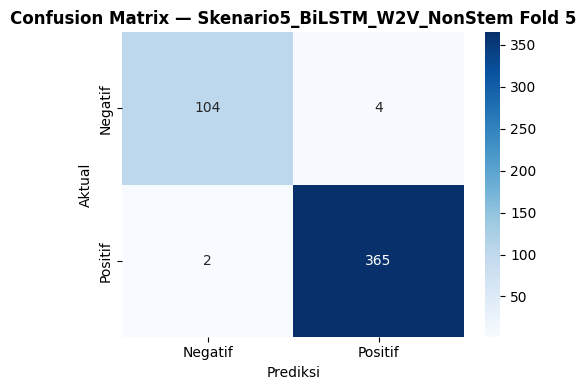

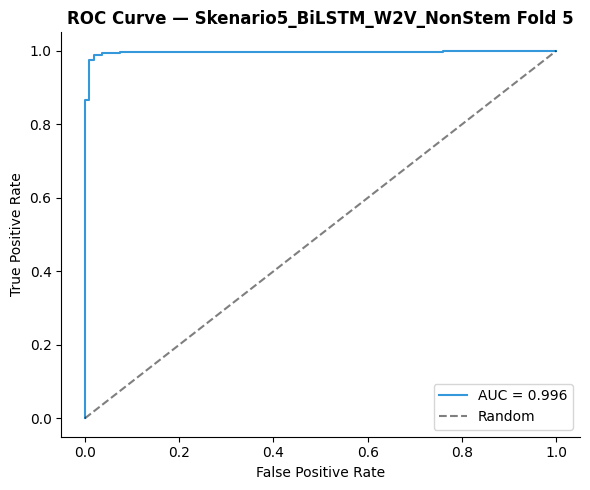


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario5_BiLSTM_W2V_NonStem/model.h5


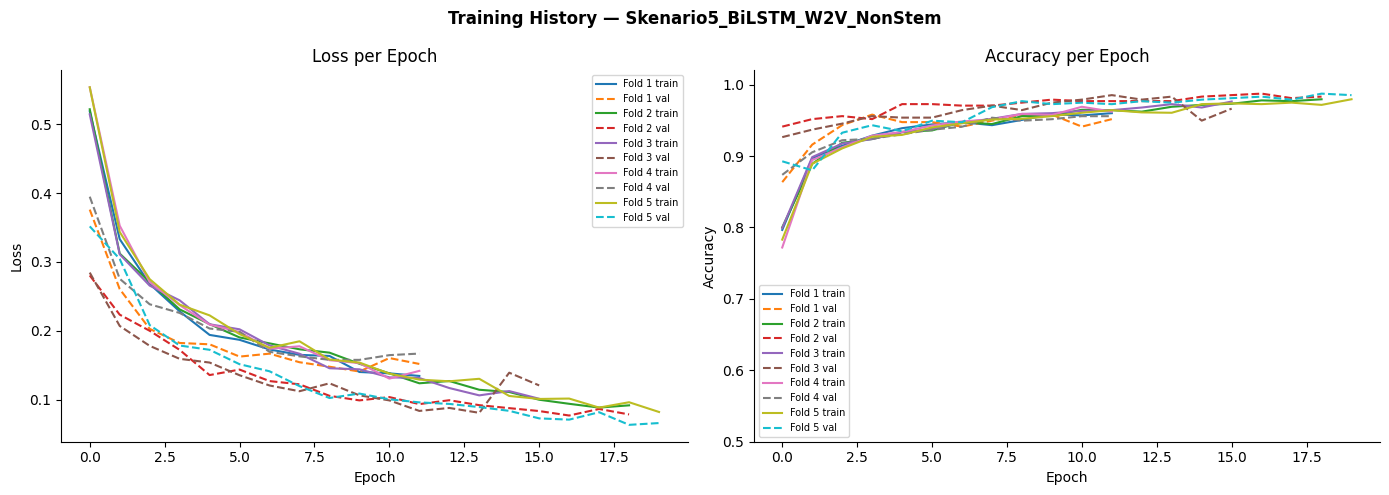


  ╔═ SELESAI: Skenario5_BiLSTM_W2V_NonStem
  ║  avg Precision  : 0.9653 ± 0.0209
  ║  avg Recall     : 0.9588 ± 0.0296
  ║  avg F1 Macro   : 0.9619 ± 0.0253
  ║  avg Accuracy   : 0.9735 ± 0.0173
  ║  avg AUC        : 0.9895 ± 0.0061
  ║  avg RAM        : 3206.5 MB (24.7%)
  ║  avg CPU        : 13.3 %
  ║  avg Waktu      : 283.12 detik/fold
  ║  avg T/Epoch    : 17.88 detik/epoch
  ║  avg T/Step     : 0.3031 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 5 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[4])


  Training: Skenario6_BiLSTM_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 273ms/step - accuracy: 0.7671 - auc: 0.7012 - loss: 0.5633 - val_accuracy: 0.9013 - val_auc: 0.9327 - val_loss: 0.3461
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 247ms/step - accuracy: 0.8906 - auc: 0.9296 - loss: 0.3253 - val_accuracy: 0.9244 - val_auc: 0.9585 - val_loss: 0.2606
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 248ms/step - accuracy: 0.9159 - auc: 0.9500 - loss: 0.2696 - val_accuracy: 0.9454 - val_auc: 0.9673 - val_loss: 0.2123
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 249ms/step - accuracy: 0.9317 - auc: 0.9656 - loss: 0.2222 - val_accuracy: 0.9454 - val_auc: 0.9710 - val_loss: 0.1964
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 250ms/step - accuracy: 0.9385 - auc: 0.9720 - loss: 0.2016 - val_a

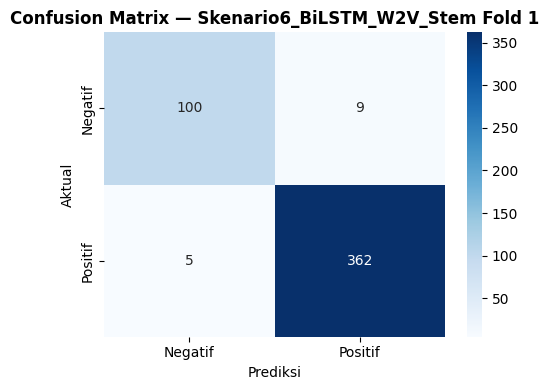

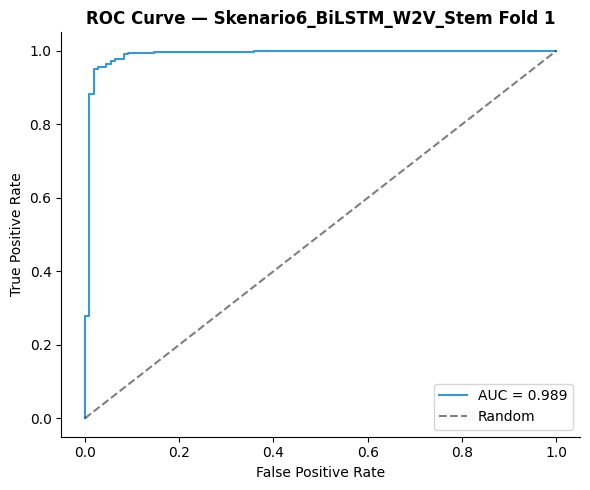


  ── Fold 2/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 262ms/step - accuracy: 0.7855 - auc: 0.7466 - loss: 0.5373 - val_accuracy: 0.9286 - val_auc: 0.9614 - val_loss: 0.3269
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 236ms/step - accuracy: 0.8880 - auc: 0.9208 - loss: 0.3404 - val_accuracy: 0.9391 - val_auc: 0.9739 - val_loss: 0.2321
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 231ms/step - accuracy: 0.9006 - auc: 0.9383 - loss: 0.2886 - val_accuracy: 0.9496 - val_auc: 0.9757 - val_loss: 0.2053
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.9232 - auc: 0.9578 - loss: 0.2431 - val_accuracy: 0.9580 - val_auc: 0.9775 - val_loss: 0.1783
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.9301 - auc: 0.9586 - loss: 0.2369 - val_accuracy: 0.9622 - val_auc: 0.9792 - val_loss: 0.1647
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.9311 - auc: 0.9636 - loss: 0.2246 - val_accuracy: 0.9559 - val_auc: 0.97

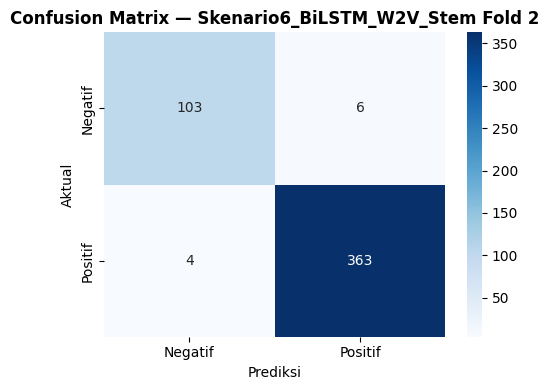

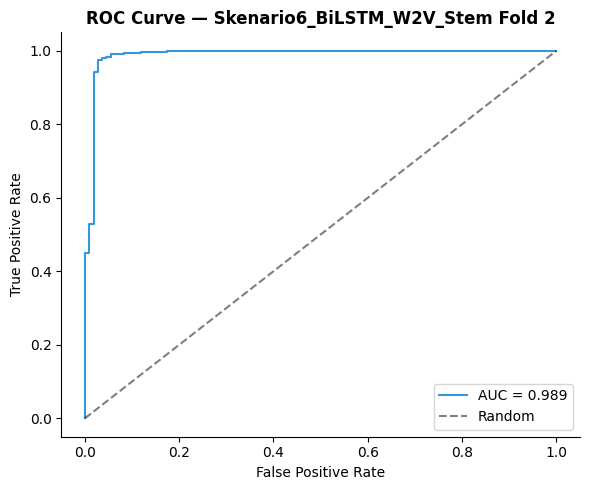


  ── Fold 3/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 266ms/step - accuracy: 0.7829 - auc: 0.7367 - loss: 0.5404 - val_accuracy: 0.9181 - val_auc: 0.9521 - val_loss: 0.3110
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step - accuracy: 0.9001 - auc: 0.9227 - loss: 0.3358 - val_accuracy: 0.9328 - val_auc: 0.9787 - val_loss: 0.2160
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.9111 - auc: 0.9404 - loss: 0.2789 - val_accuracy: 0.9370 - val_auc: 0.9838 - val_loss: 0.1915
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.9196 - auc: 0.9563 - loss: 0.2475 - val_accuracy: 0.9601 - val_auc: 0.9891 - val_loss: 0.1509
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.9374 - auc: 0.9629 - loss: 0.2196 - val_accuracy: 0.9622 - val_auc: 0.9924 - val_loss: 0.1295
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 238ms/step - accuracy: 0.9385 - auc: 0.9704 - loss: 0.1977 - val_accuracy: 0.9622 - val_auc: 0.99

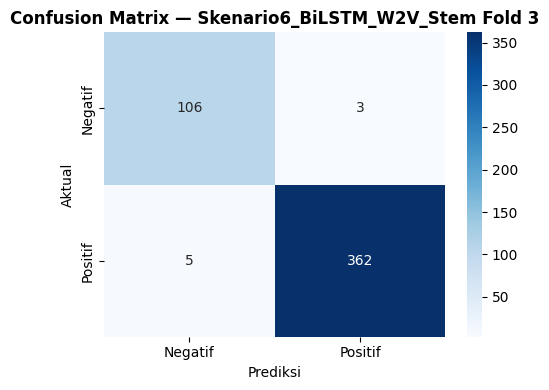

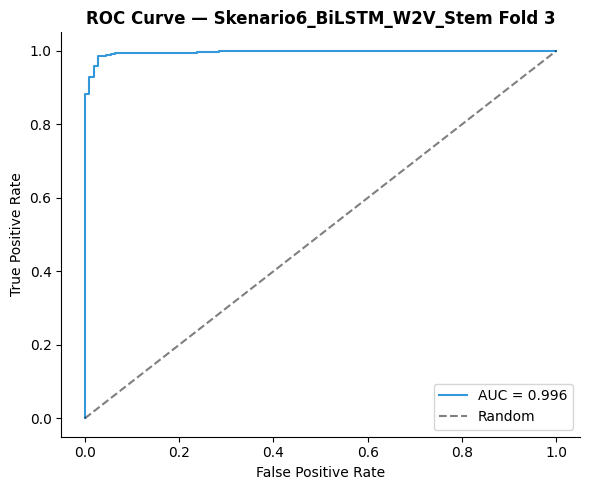


  ── Fold 4/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 265ms/step - accuracy: 0.7872 - auc: 0.7444 - loss: 0.5370 - val_accuracy: 0.8863 - val_auc: 0.9257 - val_loss: 0.3560
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.9059 - auc: 0.9314 - loss: 0.3099 - val_accuracy: 0.9137 - val_auc: 0.9563 - val_loss: 0.2685
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 249ms/step - accuracy: 0.9164 - auc: 0.9507 - loss: 0.2616 - val_accuracy: 0.9284 - val_auc: 0.9652 - val_loss: 0.2442
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 250ms/step - accuracy: 0.9254 - auc: 0.9542 - loss: 0.2386 - val_accuracy: 0.9242 - val_auc: 0.9697 - val_loss: 0.2447
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.9322 - auc: 0.9607 - loss: 0.2251 - val_accuracy: 0.9368 - val_auc: 0.9726 - val_loss: 0.2043
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 251ms/step - accuracy: 0.9390 - auc: 0.9670 - loss: 0.2040 - val_accuracy: 0.9432 - val_auc: 0.97

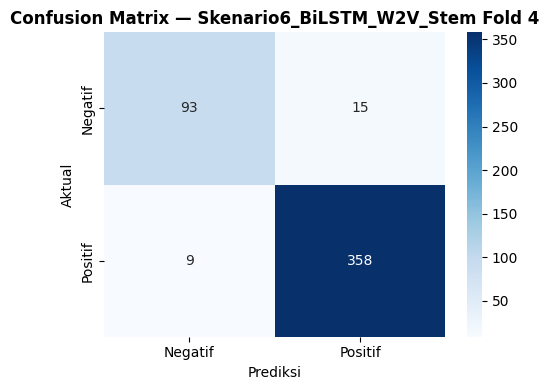

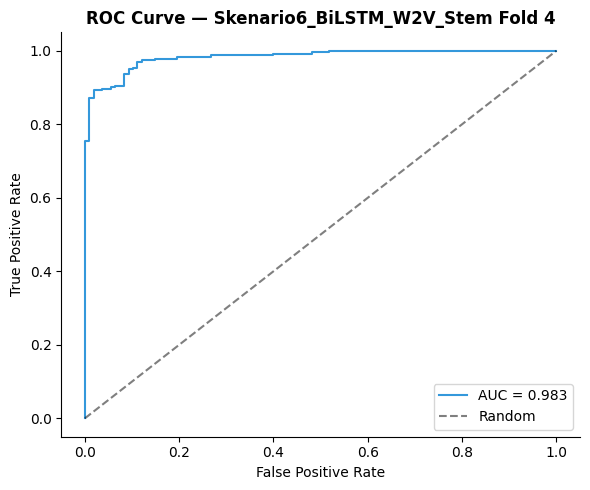


  ── Fold 5/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 267ms/step - accuracy: 0.7819 - auc: 0.7256 - loss: 0.5533 - val_accuracy: 0.9032 - val_auc: 0.9359 - val_loss: 0.3359
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 249ms/step - accuracy: 0.9054 - auc: 0.9302 - loss: 0.3197 - val_accuracy: 0.9137 - val_auc: 0.9614 - val_loss: 0.2633
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.9143 - auc: 0.9445 - loss: 0.2763 - val_accuracy: 0.9263 - val_auc: 0.9719 - val_loss: 0.2280
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.9264 - auc: 0.9529 - loss: 0.2459 - val_accuracy: 0.9305 - val_auc: 0.9788 - val_loss: 0.2010
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - accuracy: 0.9364 - auc: 0.9655 - loss: 0.2085 - val_accuracy: 0.9347 - val_auc: 0.9814 - val_loss: 0.1825
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.9375 - auc: 0.9616 - loss: 0.2129 - val_accuracy: 0.9474 - val_auc: 0.98

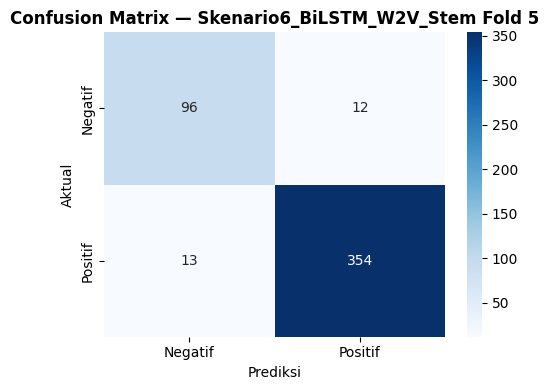

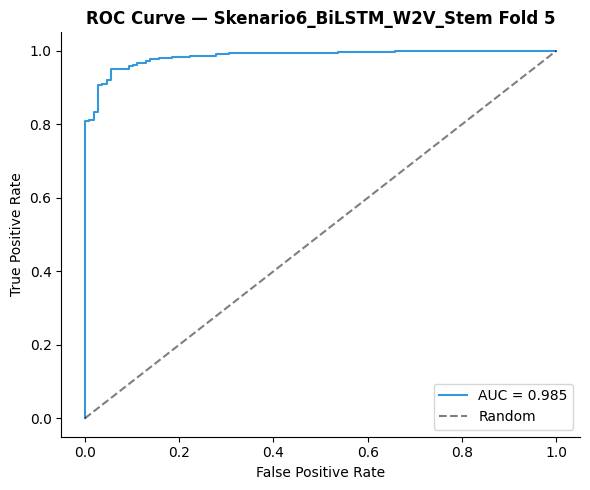


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario6_BiLSTM_W2V_Stem/model.h5


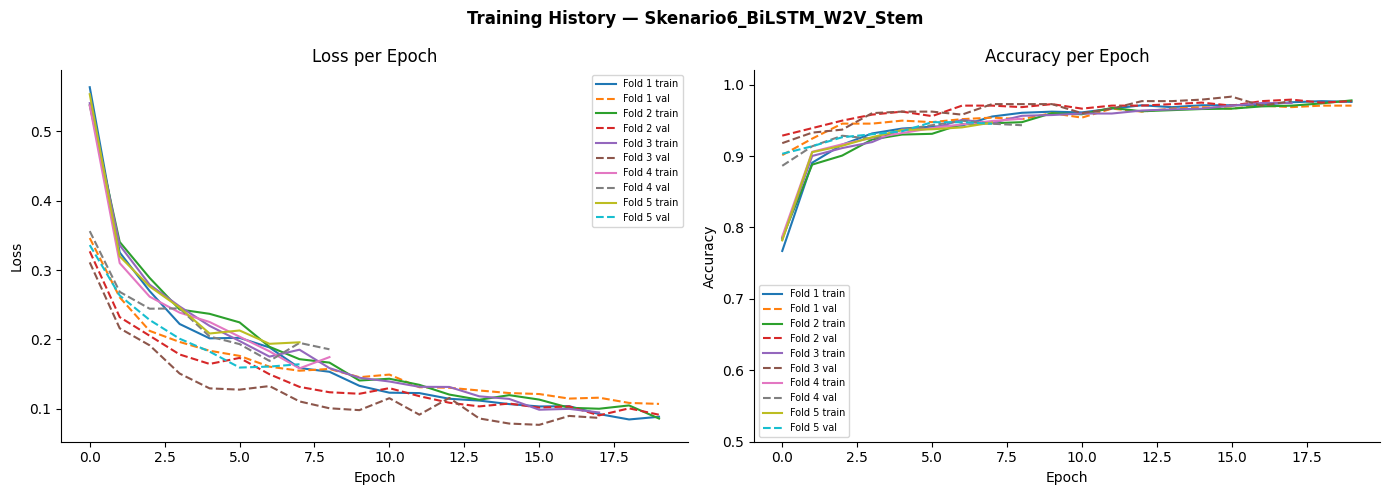


  ╔═ SELESAI: Skenario6_BiLSTM_W2V_Stem
  ║  avg Precision  : 0.9541 ± 0.0228
  ║  avg Recall     : 0.9487 ± 0.0260
  ║  avg F1 Macro   : 0.9512 ± 0.0240
  ║  avg Accuracy   : 0.9659 ± 0.0166
  ║  avg AUC        : 0.9885 ± 0.0051
  ║  avg RAM        : 3484.1 MB (26.9%)
  ║  avg CPU        : 8.2 %
  ║  avg Waktu      : 264.11 detik/fold
  ║  avg T/Epoch    : 17.46 detik/epoch
  ║  avg T/Step     : 0.2959 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 6 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[5])


  Training: Skenario7_BiLSTM_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 261ms/step - accuracy: 0.7650 - auc: 0.6845 - loss: 0.5699 - val_accuracy: 0.8824 - val_auc: 0.9146 - val_loss: 0.3723
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 243ms/step - accuracy: 0.8764 - auc: 0.9017 - loss: 0.3669 - val_accuracy: 0.8761 - val_auc: 0.9476 - val_loss: 0.3135
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.8954 - auc: 0.9287 - loss: 0.3107 - val_accuracy: 0.9139 - val_auc: 0.9615 - val_loss: 0.2638
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.9101 - auc: 0.9404 - loss: 0.2783 - val_accuracy: 0.9349 - val_auc: 0.9662 - val_loss: 0.2154
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 243ms/step - accuracy: 0.9222 - auc: 0.9526 - loss: 0.2480 - val_acc

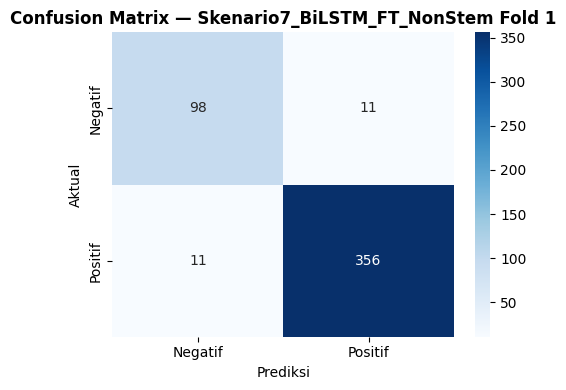

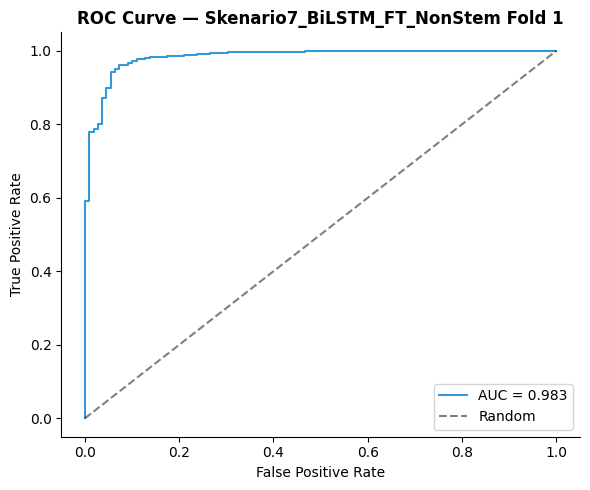


  ── Fold 2/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 302ms/step - accuracy: 0.7760 - auc: 0.6881 - loss: 0.5640 - val_accuracy: 0.9139 - val_auc: 0.9507 - val_loss: 0.3538
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 244ms/step - accuracy: 0.8491 - auc: 0.8870 - loss: 0.3914 - val_accuracy: 0.9349 - val_auc: 0.9590 - val_loss: 0.2715
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.8970 - auc: 0.9225 - loss: 0.3214 - val_accuracy: 0.9454 - val_auc: 0.9689 - val_loss: 0.2138
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.9038 - auc: 0.9393 - loss: 0.2836 - val_accuracy: 0.9412 - val_auc: 0.9730 - val_loss: 0.2058
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step - accuracy: 0.9027 - auc: 0.9445 - loss: 0.2708 - val_accuracy: 0.9538 - val_auc: 0.9728 - val_loss: 0.1838
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 228ms/step - accuracy: 0.9285 - auc: 0.9608 - loss: 0.2316 - val_accuracy: 0.9601 - val_auc: 0.97

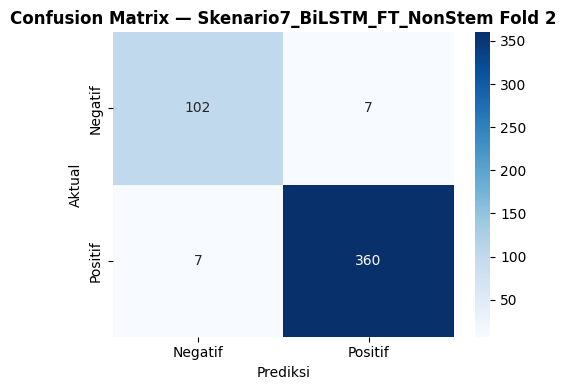

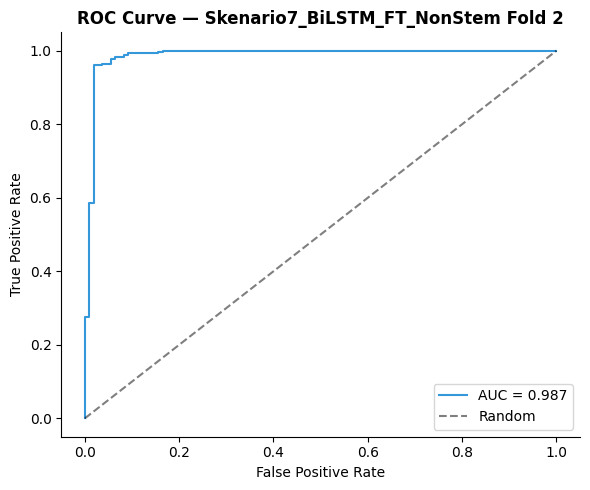


  ── Fold 3/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 263ms/step - accuracy: 0.7855 - auc: 0.6953 - loss: 0.5586 - val_accuracy: 0.8929 - val_auc: 0.9477 - val_loss: 0.3358
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 245ms/step - accuracy: 0.8728 - auc: 0.9150 - loss: 0.3496 - val_accuracy: 0.9307 - val_auc: 0.9659 - val_loss: 0.2537
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.8975 - auc: 0.9368 - loss: 0.2925 - val_accuracy: 0.9307 - val_auc: 0.9725 - val_loss: 0.2383
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 231ms/step - accuracy: 0.9096 - auc: 0.9433 - loss: 0.2776 - val_accuracy: 0.9181 - val_auc: 0.9814 - val_loss: 0.2385
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/step - accuracy: 0.9117 - auc: 0.9447 - loss: 0.2670 - val_accuracy: 0.9496 - val_auc: 0.9827 - val_loss: 0.1691
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.9253 - auc: 0.9518 - loss: 0.2473 - val_accuracy: 0.9517 - val_auc: 0.98

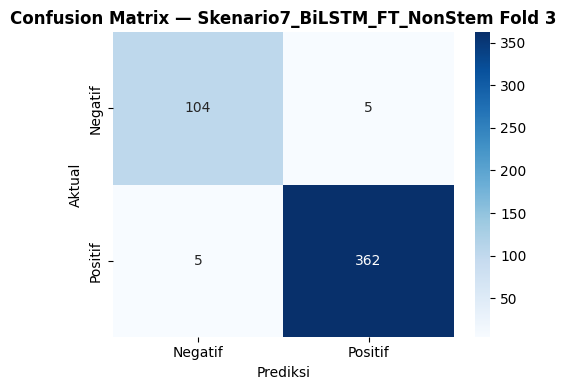

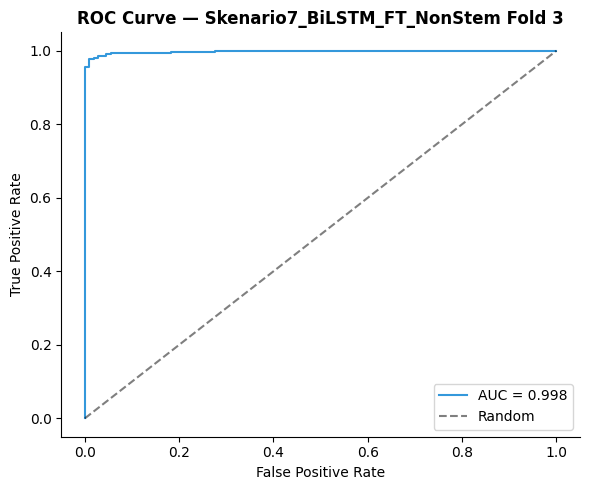


  ── Fold 4/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.7930 - auc: 0.7466 - loss: 0.5347 - val_accuracy: 0.8800 - val_auc: 0.9241 - val_loss: 0.3482
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 241ms/step - accuracy: 0.8875 - auc: 0.9095 - loss: 0.3481 - val_accuracy: 0.9032 - val_auc: 0.9400 - val_loss: 0.3086
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 229ms/step - accuracy: 0.8928 - auc: 0.9295 - loss: 0.3055 - val_accuracy: 0.9116 - val_auc: 0.9544 - val_loss: 0.2559
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/step - accuracy: 0.9065 - auc: 0.9363 - loss: 0.2839 - val_accuracy: 0.9179 - val_auc: 0.9594 - val_loss: 0.2484
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 243ms/step - accuracy: 0.9201 - auc: 0.9458 - loss: 0.2568 - val_accuracy: 0.9200 - val_auc: 0.9597 - val_loss: 0.2432
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 243ms/step - accuracy: 0.9249 - auc: 0.9586 - loss: 0.2329 - val_accuracy: 0.9389 - val_auc: 0.96

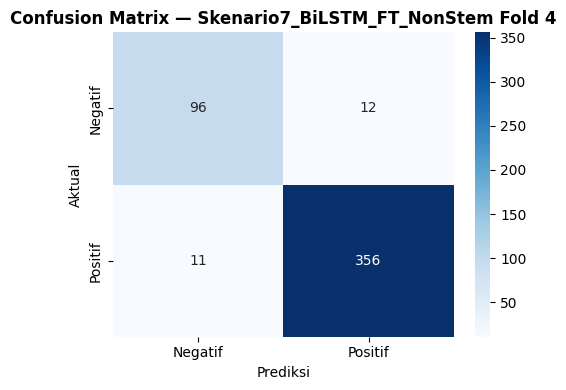

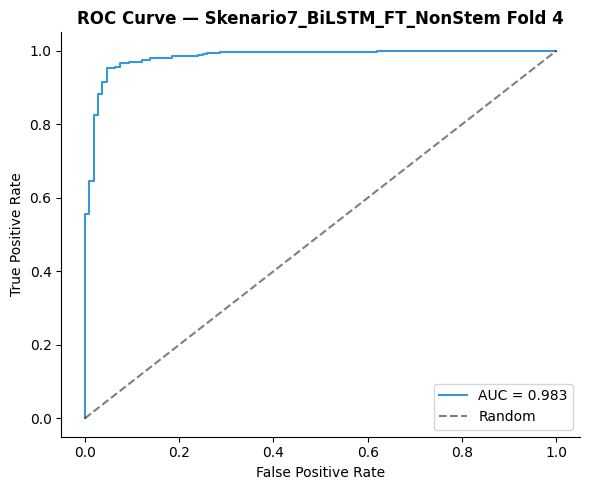


  ── Fold 5/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.7867 - auc: 0.6967 - loss: 0.5608 - val_accuracy: 0.8716 - val_auc: 0.9332 - val_loss: 0.3626
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 249ms/step - accuracy: 0.8854 - auc: 0.8998 - loss: 0.3635 - val_accuracy: 0.8905 - val_auc: 0.9514 - val_loss: 0.3126
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.8975 - auc: 0.9280 - loss: 0.3092 - val_accuracy: 0.9200 - val_auc: 0.9567 - val_loss: 0.2505
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.9044 - auc: 0.9309 - loss: 0.2960 - val_accuracy: 0.9116 - val_auc: 0.9644 - val_loss: 0.2361
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 267ms/step - accuracy: 0.9180 - auc: 0.9476 - loss: 0.2599 - val_accuracy: 0.9179 - val_auc: 0.9712 - val_loss: 0.2246
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step - accuracy: 0.9254 - auc: 0.9428 - loss: 0.2591 - val_accuracy: 0.9347 - val_auc: 0.97

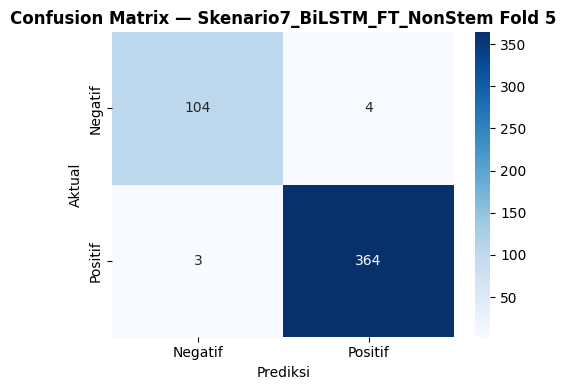

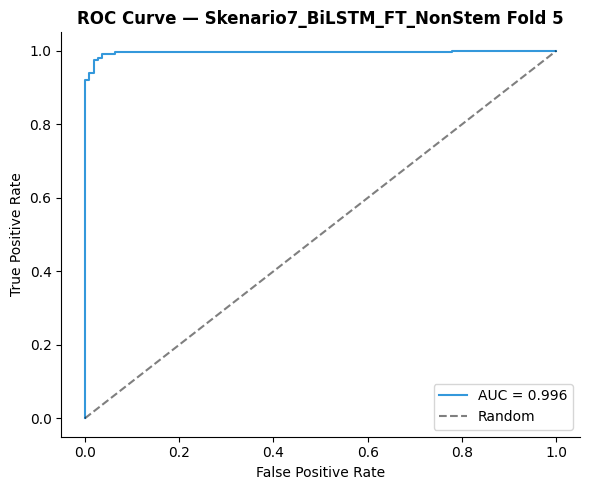


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario7_BiLSTM_FT_NonStem/model.h5


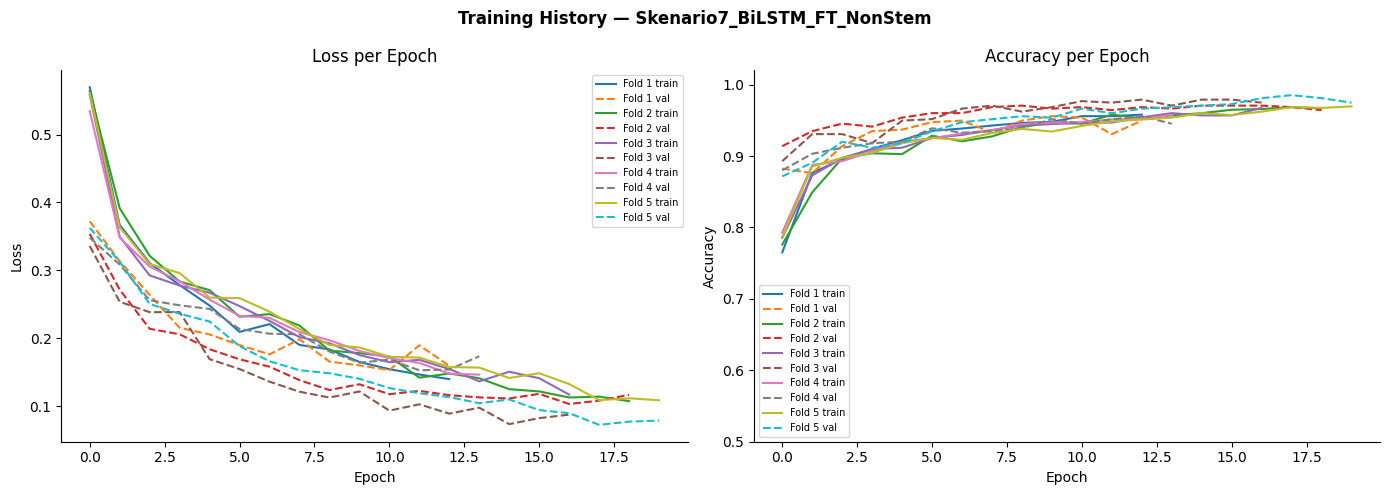


  ╔═ SELESAI: Skenario7_BiLSTM_FT_NonStem
  ║  avg Precision  : 0.9552 ± 0.0214
  ║  avg Recall     : 0.9540 ± 0.0213
  ║  avg F1 Macro   : 0.9546 ± 0.0213
  ║  avg Accuracy   : 0.9680 ± 0.0150
  ║  avg AUC        : 0.9895 ± 0.0071
  ║  avg RAM        : 3909.0 MB (30.1%)
  ║  avg CPU        : 13.1 %
  ║  avg Waktu      : 289.99 detik/fold
  ║  avg T/Epoch    : 17.36 detik/epoch
  ║  avg T/Step     : 0.2942 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 7 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[6])


  Training: Skenario8_BiLSTM_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.7744 - auc: 0.7010 - loss: 0.5580 - val_accuracy: 0.8761 - val_auc: 0.9228 - val_loss: 0.3644
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 239ms/step - accuracy: 0.8733 - auc: 0.9060 - loss: 0.3618 - val_accuracy: 0.9160 - val_auc: 0.9471 - val_loss: 0.2808
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.9048 - auc: 0.9294 - loss: 0.3042 - val_accuracy: 0.9223 - val_auc: 0.9529 - val_loss: 0.2507
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.9127 - auc: 0.9458 - loss: 0.2638 - val_accuracy: 0.9328 - val_auc: 0.9624 - val_loss: 0.2256
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.9154 - auc: 0.9525 - loss: 0.2510 - val_accura

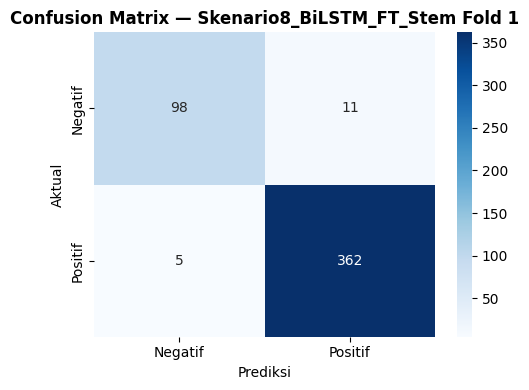

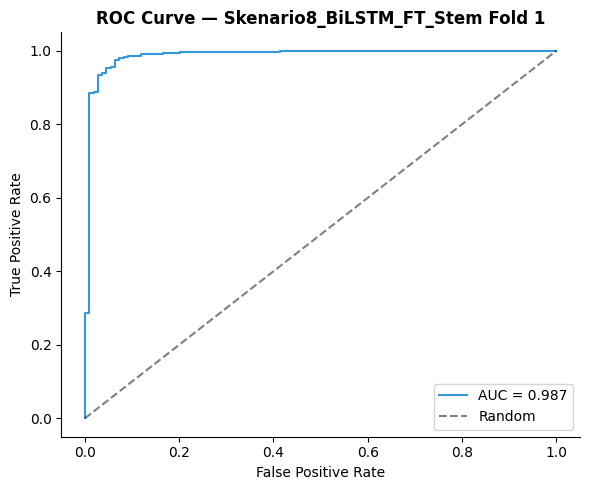


  ── Fold 2/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 266ms/step - accuracy: 0.7692 - auc: 0.6648 - loss: 0.5810 - val_accuracy: 0.9139 - val_auc: 0.9572 - val_loss: 0.3365
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 251ms/step - accuracy: 0.8707 - auc: 0.8922 - loss: 0.3834 - val_accuracy: 0.9286 - val_auc: 0.9621 - val_loss: 0.2639
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.8885 - auc: 0.9177 - loss: 0.3271 - val_accuracy: 0.9370 - val_auc: 0.9697 - val_loss: 0.2391
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.9001 - auc: 0.9388 - loss: 0.2901 - val_accuracy: 0.9370 - val_auc: 0.9716 - val_loss: 0.2176
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 238ms/step - accuracy: 0.9075 - auc: 0.9460 - loss: 0.2645 - val_accuracy: 0.9475 - val_auc: 0.9731 - val_loss: 0.2021
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - accuracy: 0.9059 - auc: 0.9515 - loss: 0.2559 - val_accuracy: 0.9454 - val_auc: 0.97

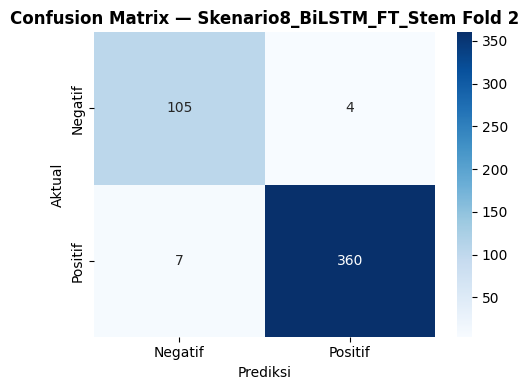

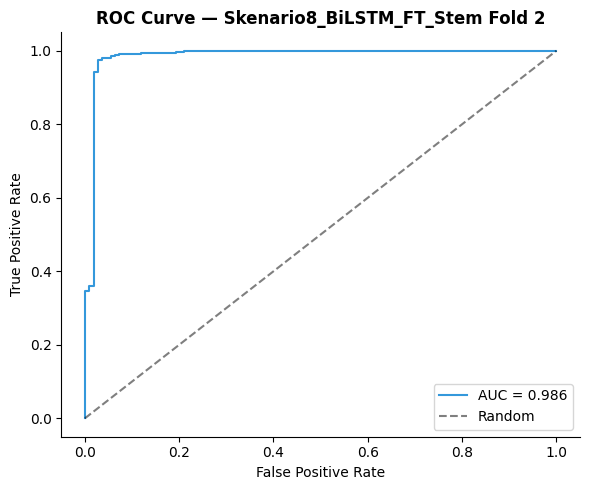


  ── Fold 3/5 ──
  Distribusi train: Pos=1468, Neg=434
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 272ms/step - accuracy: 0.7976 - auc: 0.7536 - loss: 0.5295 - val_accuracy: 0.9076 - val_auc: 0.9540 - val_loss: 0.3026
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 245ms/step - accuracy: 0.8722 - auc: 0.9045 - loss: 0.3640 - val_accuracy: 0.9265 - val_auc: 0.9697 - val_loss: 0.2382
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 255ms/step - accuracy: 0.8938 - auc: 0.9340 - loss: 0.3055 - val_accuracy: 0.9370 - val_auc: 0.9730 - val_loss: 0.2150
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 260ms/step - accuracy: 0.9138 - auc: 0.9475 - loss: 0.2652 - val_accuracy: 0.9496 - val_auc: 0.9831 - val_loss: 0.1754
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.9143 - auc: 0.9492 - loss: 0.2581 - val_accuracy: 0.9475 - val_auc: 0.9835 - val_loss: 0.1838
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 238ms/step - accuracy: 0.9301 - auc: 0.9612 - loss: 0.2243 - val_accuracy: 0.9559 - val_auc: 0.98

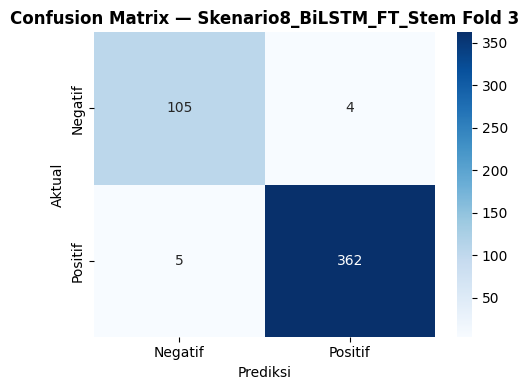

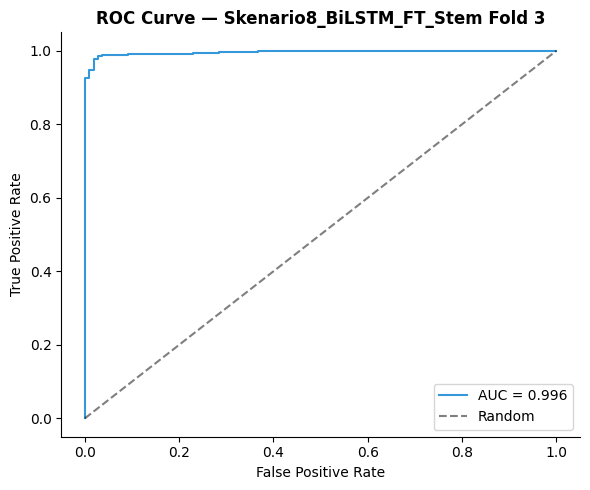


  ── Fold 4/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 266ms/step - accuracy: 0.7751 - auc: 0.7152 - loss: 0.5508 - val_accuracy: 0.8968 - val_auc: 0.9195 - val_loss: 0.3785
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 245ms/step - accuracy: 0.8828 - auc: 0.9171 - loss: 0.3481 - val_accuracy: 0.8989 - val_auc: 0.9482 - val_loss: 0.2843
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.9033 - auc: 0.9340 - loss: 0.2966 - val_accuracy: 0.9179 - val_auc: 0.9596 - val_loss: 0.2615
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step - accuracy: 0.9059 - auc: 0.9383 - loss: 0.2846 - val_accuracy: 0.9179 - val_auc: 0.9618 - val_loss: 0.2371
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 237ms/step - accuracy: 0.9217 - auc: 0.9553 - loss: 0.2445 - val_accuracy: 0.9347 - val_auc: 0.9696 - val_loss: 0.2079
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.9254 - auc: 0.9582 - loss: 0.2278 - val_accuracy: 0.9347 - val_auc: 0.97

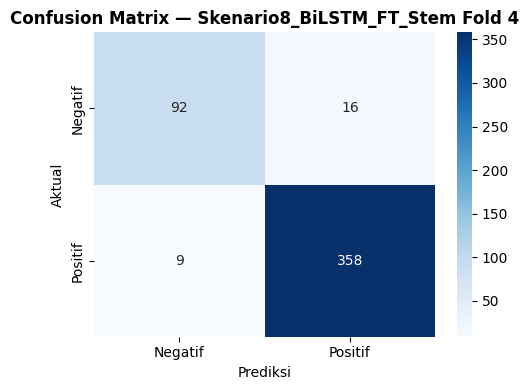

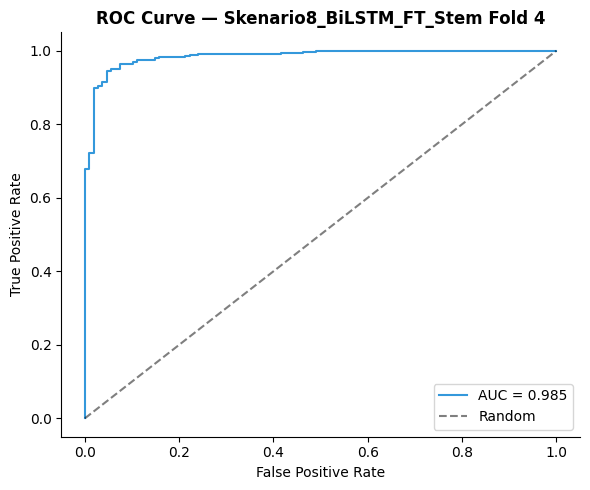


  ── Fold 5/5 ──
  Distribusi train: Pos=1468, Neg=435
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 267ms/step - accuracy: 0.7704 - auc: 0.6516 - loss: 0.5793 - val_accuracy: 0.8779 - val_auc: 0.9194 - val_loss: 0.3862
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 248ms/step - accuracy: 0.8812 - auc: 0.9002 - loss: 0.3685 - val_accuracy: 0.8926 - val_auc: 0.9449 - val_loss: 0.3064
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.8928 - auc: 0.9313 - loss: 0.3119 - val_accuracy: 0.9179 - val_auc: 0.9617 - val_loss: 0.2458
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.9091 - auc: 0.9395 - loss: 0.2809 - val_accuracy: 0.9305 - val_auc: 0.9706 - val_loss: 0.2200
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.9212 - auc: 0.9479 - loss: 0.2587 - val_accuracy: 0.9347 - val_auc: 0.9763 - val_loss: 0.1985
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 252ms/step - accuracy: 0.9338 - auc: 0.9607 - loss: 0.2285 - val_accuracy: 0.9368 - val_auc: 0.98

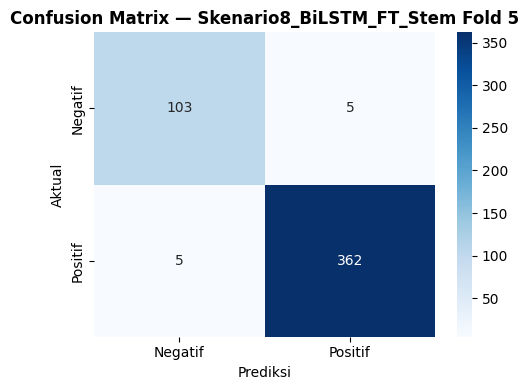

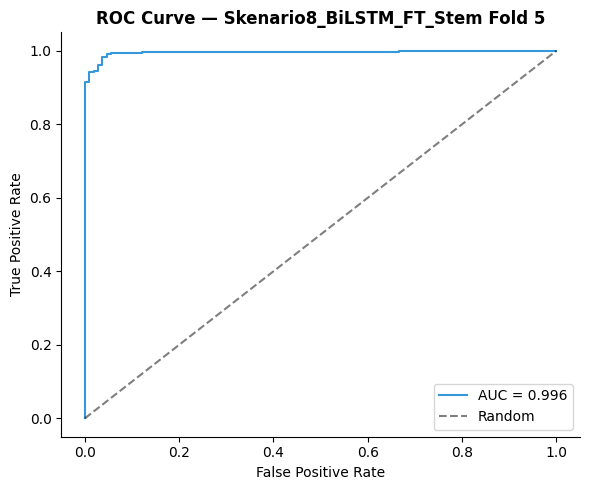


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario8_BiLSTM_FT_Stem/model.h5


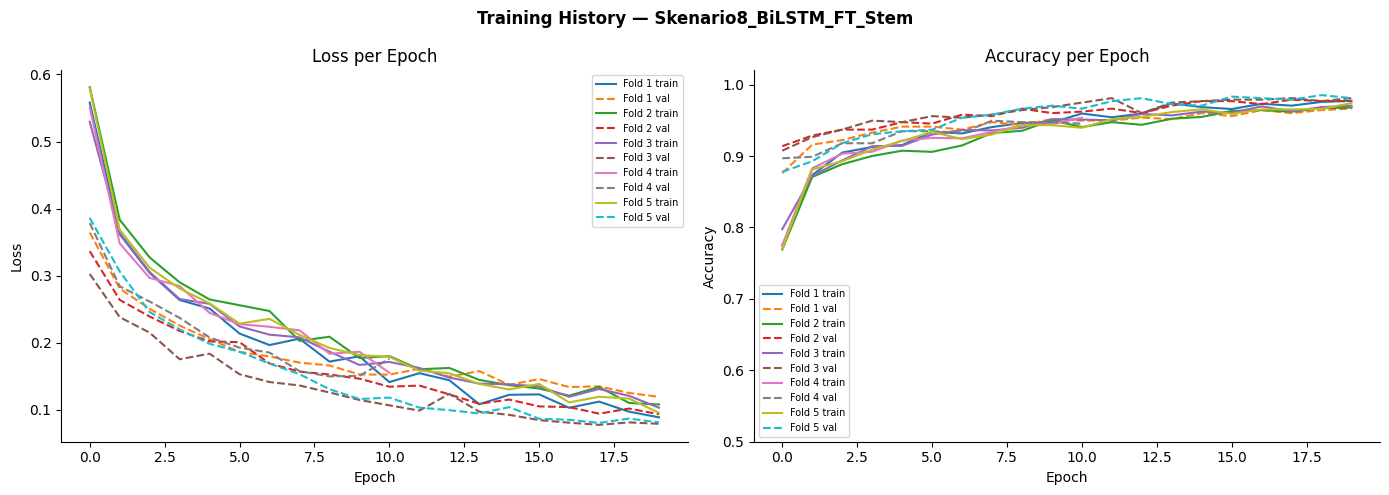


  ╔═ SELESAI: Skenario8_BiLSTM_FT_Stem
  ║  avg Precision  : 0.9600 ± 0.0152
  ║  avg Recall     : 0.9547 ± 0.0263
  ║  avg F1 Macro   : 0.9571 ± 0.0207
  ║  avg Accuracy   : 0.9701 ± 0.0139
  ║  avg AUC        : 0.9901 ± 0.0055
  ║  avg RAM        : 4167.2 MB (32.1%)
  ║  avg CPU        : 5.8 %
  ║  avg Waktu      : 324.72 detik/fold
  ║  avg T/Epoch    : 17.66 detik/epoch
  ║  avg T/Step     : 0.2993 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 8 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[7])

## 8. Rekap Hasil & Simpan ke Excel


In [ ]:
# Load rekap CSV lalu simpan ke Excel
drive.mount('/content/drive')
df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task4_semua_skenario.csv')

# Urutkan berdasarkan F1 Macro tertinggi
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)

print('=== Rekap Semua Skenario (urut F1 Macro) ===')
cols_tampil = ['skenario', 'avg_f1_macro', 'std_f1_macro',
               'avg_accuracy', 'avg_precision_macro',
               'avg_recall_macro', 'avg_auc']
print(df_rekap[cols_tampil].to_string(index=False))

# Simpan ke Excel
excel_path = OUTPUT_DIR + 'rekap_Task4_semua_skenario.xlsx'
df_rekap.to_excel(excel_path, index=False)
print(f'\nDisimpan ke: {excel_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Rekap Semua Skenario (urut F1 Macro) ===
                    skenario  avg_f1_macro  std_f1_macro  avg_accuracy  avg_precision_macro  avg_recall_macro  avg_auc
   Skenario1_CNN_W2V_NonStem        0.9737        0.0106        0.9815               0.9745            0.9731   0.9947
    Skenario3_CNN_FT_NonStem        0.9725        0.0070        0.9807               0.9732            0.9719   0.9944
      Skenario2_CNN_W2V_Stem        0.9717        0.0070        0.9802               0.9760            0.9677   0.9943
       Skenario4_CNN_FT_Stem        0.9676        0.0073        0.9773               0.9696            0.9658   0.9939
Skenario5_BiLSTM_W2V_NonStem        0.9619        0.0253        0.9735               0.9653            0.9588   0.9895
    Skenario8_BiLSTM_FT_Stem        0.9571        0.0207        0.9701               0.9600            0.9547   

In [ ]:
# Load rekap CSV lalu simpan ke Excel
df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task4_semua_skenario.csv')

# Urutkan berdasarkan F1 Macro tertinggi
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)
df_rekap.insert(0, 'rank', range(1, len(df_rekap) + 1))

print('='*100)
print('  REKAP SEMUA SKENARIO TASK 4 — SENTIMEN LOCATION')
print('  Diurutkan berdasarkan F1 Macro Tertinggi')
print('='*100)

# Tampilkan per kelompok metrik
cols_utama = ['rank', 'skenario',
              'avg_f1_macro', 'std_f1_macro',
              'avg_precision_macro', 'std_precision_macro',
              'avg_recall_macro', 'std_recall_macro',
              'avg_accuracy', 'std_accuracy',
              'avg_auc', 'std_auc']

cols_resource = ['rank', 'skenario',
    'avg_waktu_training',  'std_waktu_training',
    'avg_waktu_inference', 'std_waktu_inference',
    'avg_time_per_epoch',  'std_time_per_epoch',
    'avg_time_per_step',   'std_time_per_step',
    'avg_ram_mb',          'std_ram_mb',
    'avg_ram_pct',         'std_ram_pct',
    'avg_cpu_pct',         'std_cpu_pct',
    'avg_epoch_berhenti',  'std_epoch_berhenti']

# Filter kolom yang ada saja
cols_utama    = [c for c in cols_utama    if c in df_rekap.columns]
cols_resource = [c for c in cols_resource if c in df_rekap.columns]

print('\n── Metrik Performa ──')
print(df_rekap[cols_utama].to_string(index=False))

print('\n── Resource Usage ──')
print(df_rekap[cols_resource].to_string(index=False))

# Highlight model terbaik
best = df_rekap.iloc[0]
print('\n' + '='*100)
print(f'     MODEL TERBAIK : {best["skenario"]}')
print(f'     F1 Macro     : {best["avg_f1_macro"]:.4f} ± {best["std_f1_macro"]:.4f}')
print(f'     Precision    : {best["avg_precision_macro"]:.4f} ± {best["std_precision_macro"]:.4f}')
print(f'     Recall       : {best["avg_recall_macro"]:.4f} ± {best["std_recall_macro"]:.4f}')
print(f'     Accuracy     : {best["avg_accuracy"]:.4f} ± {best["std_accuracy"]:.4f}')
print(f'     AUC          : {best["avg_auc"]:.4f} ± {best["std_auc"]:.4f}')
print('='*100)

# Simpan ke Excel dengan formatting
excel_path = OUTPUT_DIR + 'rekap_Task4_semua_skenario.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Sheet 1: Semua metrik
    df_rekap.to_excel(writer, sheet_name='Rekap_Lengkap', index=False)

    # Sheet 2: Ringkasan
    cols_ringkasan = [c for c in [
        'rank', 'skenario',
        'avg_f1_macro', 'std_f1_macro',
        'avg_precision_macro', 'avg_recall_macro',
        'avg_accuracy', 'avg_auc',
        'avg_waktu_training', 'avg_ram_mb'
    ] if c in df_rekap.columns]

    df_rekap[cols_ringkasan].to_excel(
        writer, sheet_name='Ringkasan', index=False
    )

print(f'\n✅ Disimpan ke : {excel_path}')

  REKAP SEMUA SKENARIO TASK 4 — SENTIMEN LOCATION
  Diurutkan berdasarkan F1 Macro Tertinggi

── Metrik Performa ──
 rank                     skenario  avg_f1_macro  std_f1_macro  avg_precision_macro  std_precision_macro  avg_recall_macro  std_recall_macro  avg_accuracy  std_accuracy  avg_auc  std_auc
    1    Skenario1_CNN_W2V_NonStem        0.9737        0.0106               0.9745               0.0128            0.9731            0.0107        0.9815        0.0075   0.9947   0.0020
    2     Skenario3_CNN_FT_NonStem        0.9725        0.0070               0.9732               0.0072            0.9719            0.0089        0.9807        0.0048   0.9944   0.0026
    3       Skenario2_CNN_W2V_Stem        0.9717        0.0070               0.9760               0.0085            0.9677            0.0088        0.9802        0.0049   0.9943   0.0028
    4        Skenario4_CNN_FT_Stem        0.9676        0.0073               0.9696               0.0072            0.9658            0.


Plot: Skenario1_CNN_W2V_NonStem


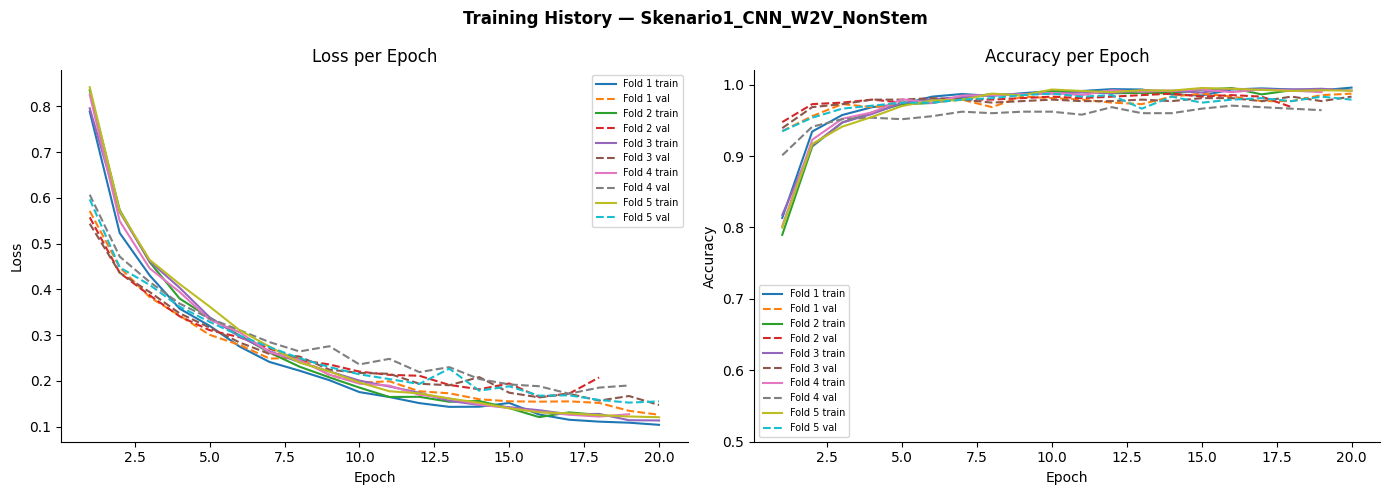

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario1_CNN_W2V_NonStem/training_history_accuracy.png

Plot: Skenario2_CNN_W2V_Stem


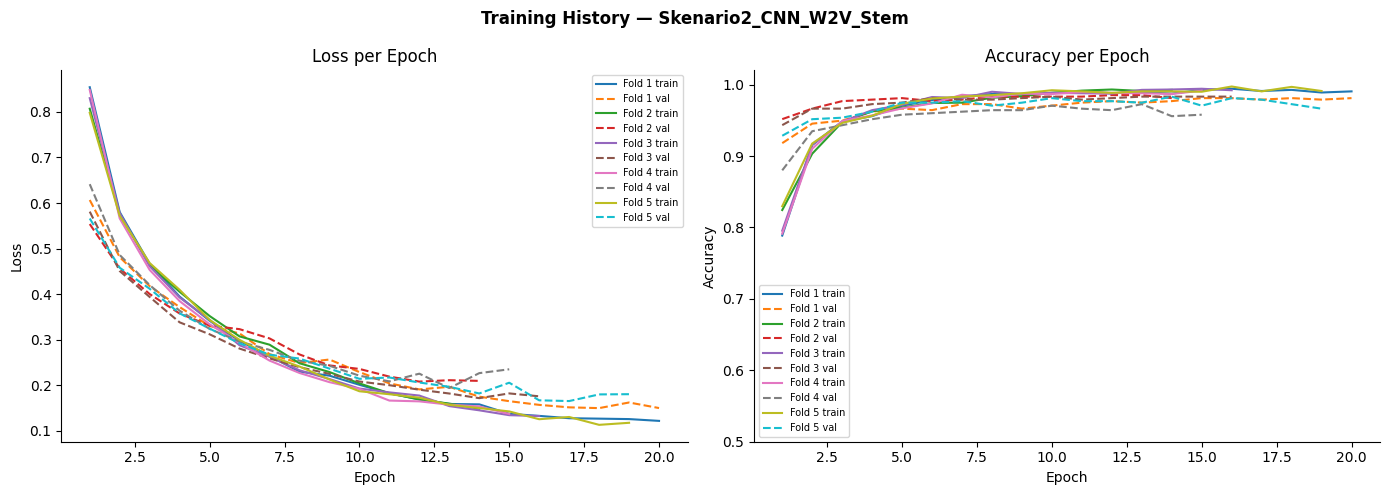

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario2_CNN_W2V_Stem/training_history_accuracy.png

Plot: Skenario3_CNN_FT_NonStem


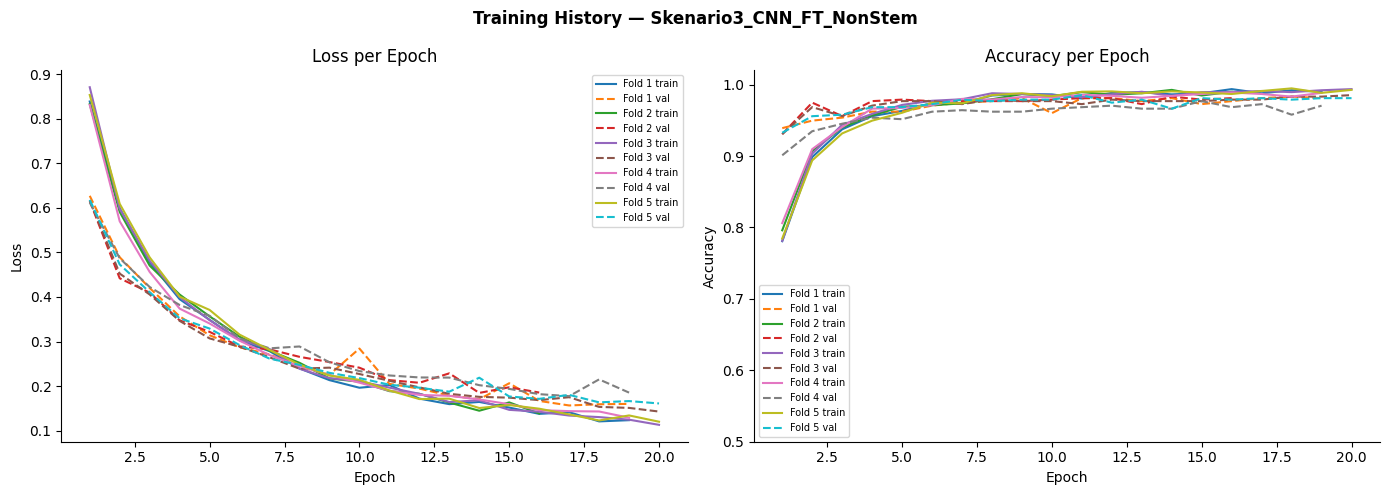

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario3_CNN_FT_NonStem/training_history_accuracy.png

Plot: Skenario4_CNN_FT_Stem


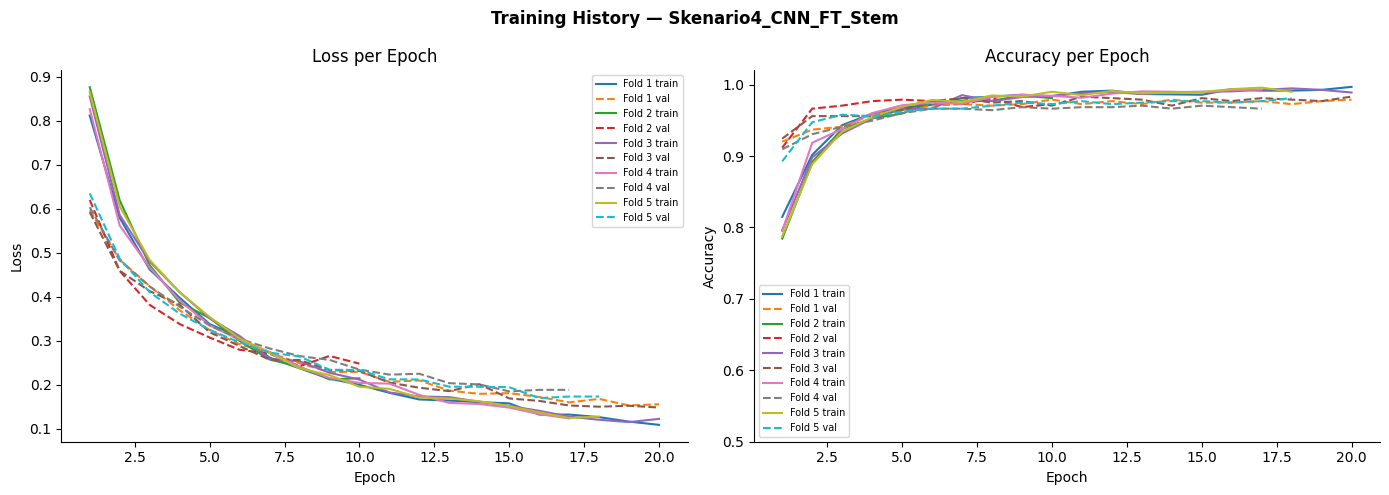

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario4_CNN_FT_Stem/training_history_accuracy.png

Plot: Skenario5_BiLSTM_W2V_NonStem


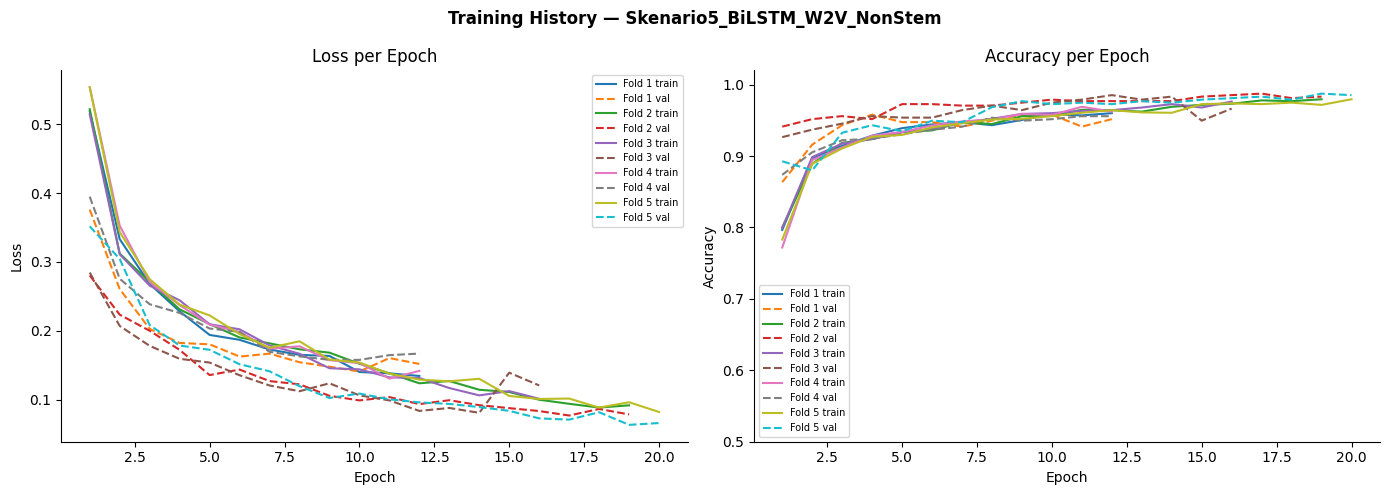

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario5_BiLSTM_W2V_NonStem/training_history_accuracy.png

Plot: Skenario6_BiLSTM_W2V_Stem


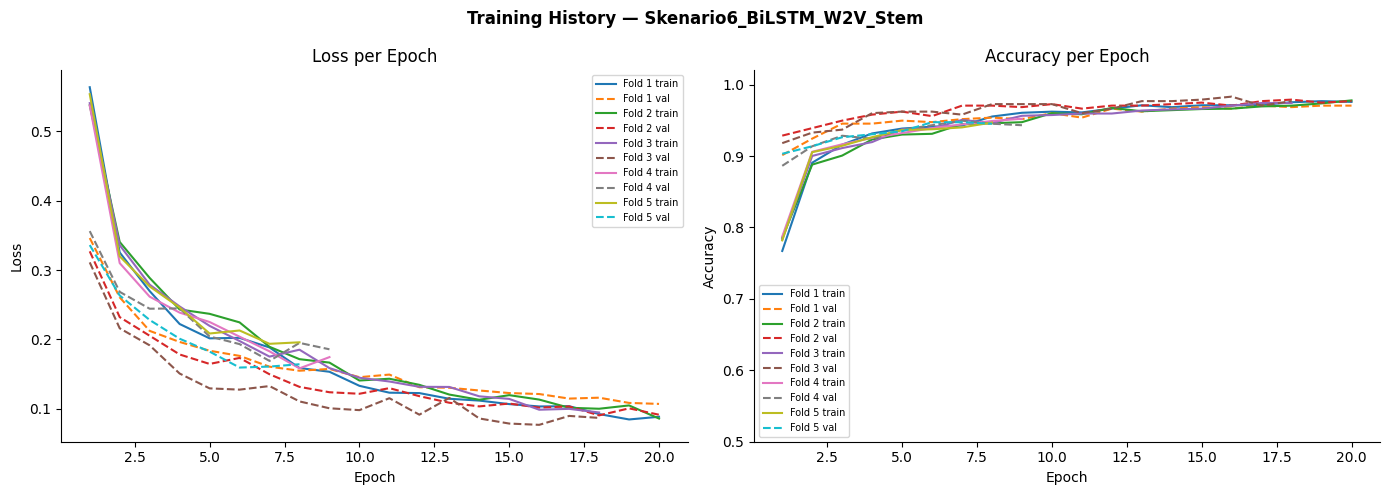

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario6_BiLSTM_W2V_Stem/training_history_accuracy.png

Plot: Skenario7_BiLSTM_FT_NonStem


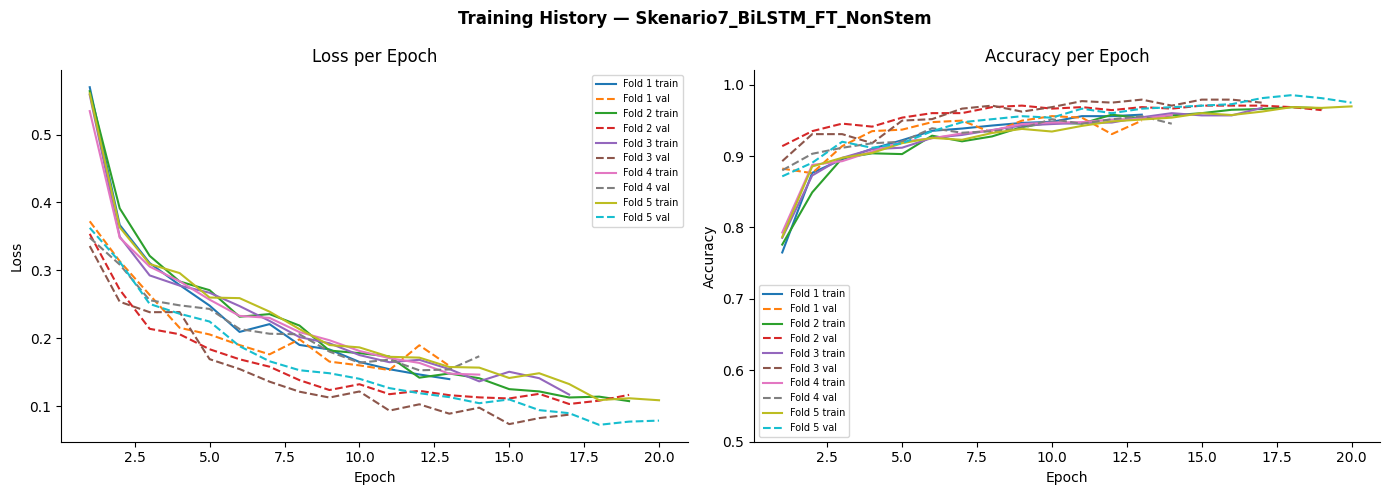

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario7_BiLSTM_FT_NonStem/training_history_accuracy.png

Plot: Skenario8_BiLSTM_FT_Stem


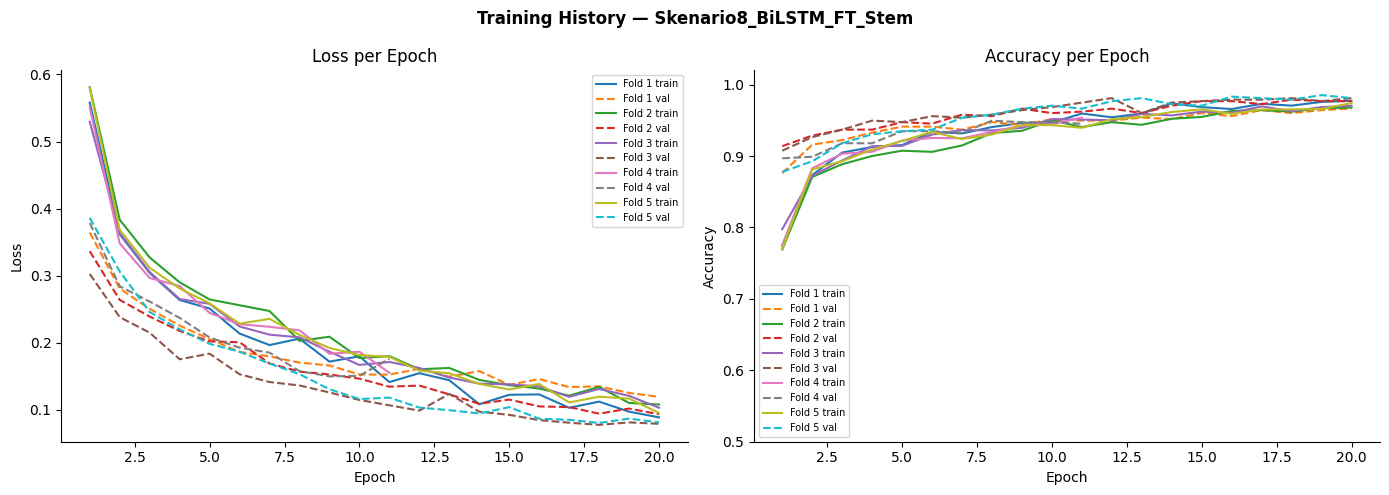

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task4_Location/Skenario8_BiLSTM_FT_Stem/training_history_accuracy.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_ulang_dari_csv(skenario_dir, nama_skenario):
    # Load history CSV
    df = pd.read_csv(skenario_dir + 'history_per_fold.csv')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold_ke in sorted(df['fold'].unique()):
        df_fold = df[df['fold'] == fold_ke]
        label   = f'Fold {fold_ke}'

        # Loss
        axes[0].plot(df_fold['epoch'], df_fold['loss'],
                     linestyle='-',  label=f'{label} train')
        axes[0].plot(df_fold['epoch'], df_fold['val_loss'],
                     linestyle='--', label=f'{label} val')

        # Accuracy
        axes[1].plot(df_fold['epoch'], df_fold['accuracy'],
                     linestyle='-',  label=f'{label} train')
        axes[1].plot(df_fold['epoch'], df_fold['val_accuracy'],
                     linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend(fontsize=7)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(f'Training History — {nama_skenario}', fontweight='bold')
    plt.tight_layout()

    # Simpan
    output_path = skenario_dir + 'training_history_accuracy.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'✅ Disimpan: {output_path}')


# ── Jalankan untuk semua skenario Task 4 ──
BASE_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/'
TASK4_DIR   = BASE_DIR + 'Dataset/Dataset_Modelling/Task4_Location/'

skenario_list = [
    'Skenario1_CNN_W2V_NonStem',
    'Skenario2_CNN_W2V_Stem',
    'Skenario3_CNN_FT_NonStem',
    'Skenario4_CNN_FT_Stem',
    'Skenario5_BiLSTM_W2V_NonStem',
    'Skenario6_BiLSTM_W2V_Stem',
    'Skenario7_BiLSTM_FT_NonStem',
    'Skenario8_BiLSTM_FT_Stem',
]

for nama in skenario_list:
    path = TASK4_DIR + nama + '/'
    csv  = path + 'history_per_fold.csv'
    if os.path.exists(csv):
        print(f'\nPlot: {nama}')
        plot_ulang_dari_csv(path, nama)
    else:
        print(f'Skip {nama} — belum ada CSV')

## 9. Rekomendasi Model Terbaik


In [ ]:
# Model terbaik = F1 Macro tertinggi
model_terbaik = df_rekap.iloc[0]
print('=== Model Terbaik Task 4 ===')
print(f"Skenario    : {model_terbaik['skenario']}")
print(f"avg F1 Macro: {model_terbaik['avg_f1_macro']:.4f} ± {model_terbaik['std_f1_macro']:.4f}")
print(f"avg Accuracy: {model_terbaik['avg_accuracy']:.4f}")
print(f"avg AUC     : {model_terbaik['avg_auc']:.4f}")


=== Model Terbaik Task 4 ===
Skenario    : Skenario1_CNN_W2V_NonStem
avg F1 Macro: 0.9737 ± 0.0106
avg Accuracy: 0.9815
avg AUC     : 0.9947


## 10. Visualisasi Perbandingan Semua Skenario


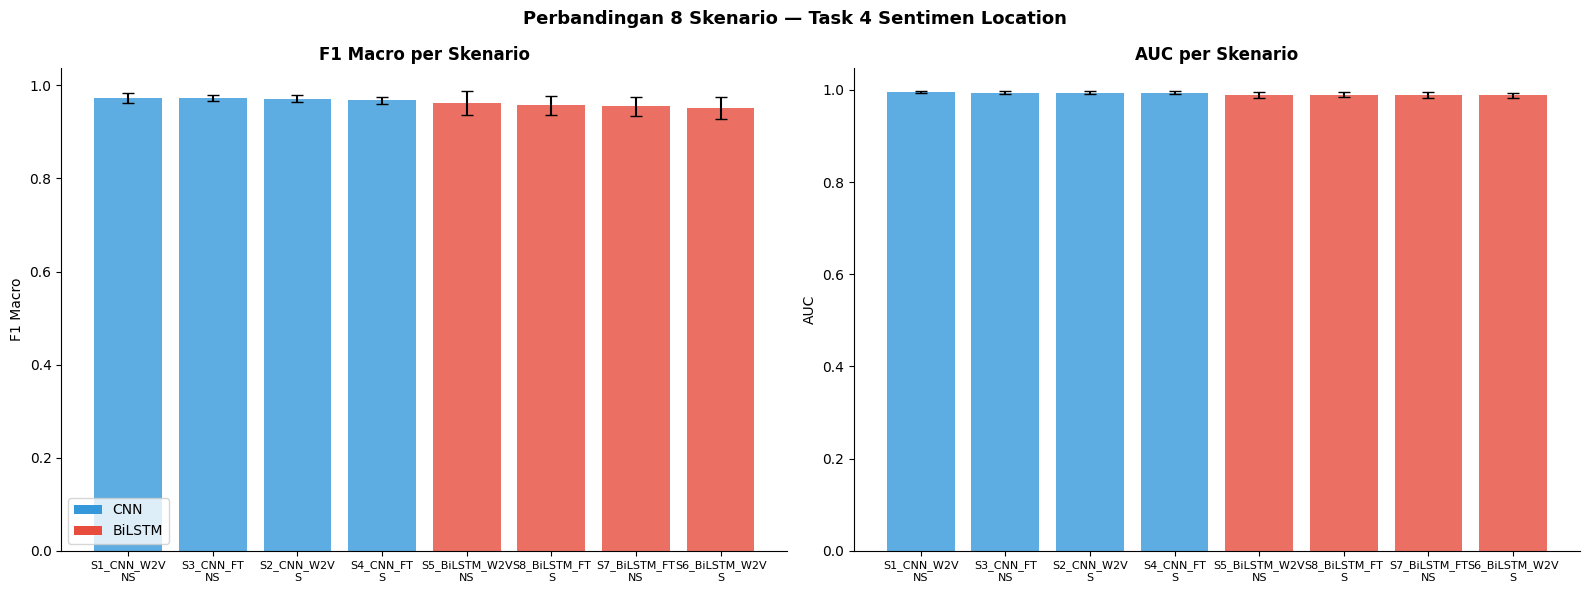

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#3498db' if 'CNN' in s else '#e74c3c'
          for s in df_rekap['skenario']]
labels_short = [s.replace('Skenario','S').replace('_NonStem','\nNS').replace('_Stem','\nS')
                for s in df_rekap['skenario']]

# F1 Macro
bars = axes[0].bar(range(len(df_rekap)), df_rekap['avg_f1_macro'],
                   color=colors, alpha=0.8)
axes[0].errorbar(range(len(df_rekap)), df_rekap['avg_f1_macro'],
                 yerr=df_rekap['std_f1_macro'], fmt='none',
                 color='black', capsize=4)
axes[0].set_xticks(range(len(df_rekap)))
axes[0].set_xticklabels(labels_short, fontsize=8)
axes[0].set_title('F1 Macro per Skenario', fontweight='bold')
axes[0].set_ylabel('F1 Macro')
axes[0].spines[['top','right']].set_visible(False)

# AUC
axes[1].bar(range(len(df_rekap)), df_rekap['avg_auc'],
            color=colors, alpha=0.8)
axes[1].errorbar(range(len(df_rekap)), df_rekap['avg_auc'],
                 yerr=df_rekap['std_auc'], fmt='none',
                 color='black', capsize=4)
axes[1].set_xticks(range(len(df_rekap)))
axes[1].set_xticklabels(labels_short, fontsize=8)
axes[1].set_title('AUC per Skenario', fontweight='bold')
axes[1].set_ylabel('AUC')
axes[1].spines[['top','right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='CNN'),
    Patch(facecolor='#e74c3c', label='BiLSTM')
]
axes[0].legend(handles=legend_elements)

plt.suptitle('Perbandingan 8 Skenario — Task 4 Sentimen Location',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'perbandingan_skenario_Task4.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 11. Dummy Classifier

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report

# ============================================================
# DUMMY CLASSIFIER BASELINE — Task 4 Sentimen Location
# (LABEL_COL sesuai task masing-masing)
# ============================================================

print('='*60)
print('  DUMMY CLASSIFIER BASELINE')
print('  Strategi: majority class (tebak kelas terbanyak)')
print('='*60)

# Data train dan test sudah ada dari cell sebelumnya
# y_train = label training
# y_test  = label test (load dulu kalau belum)

# Kalau y_test belum ada, load dulu:
df_test  = pd.read_csv(SPLIT_DIR + 'df_test_Task4_Location.csv')
y_test   = df_test[LABEL_COL].values

print(f'\n  Distribusi data train:')
print(f'  Positif : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'  Negatif : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')

print(f'\n  Distribusi data test:')
print(f'  Positif : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')
print(f'  Negatif : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')

# Strategi 1: most_frequent (tebak majority class)
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_majority.fit(y_train.reshape(-1,1), y_train)
y_pred_majority = dummy_majority.predict(y_test.reshape(-1,1))

# Strategi 2: stratified (tebak random sesuai proporsi)
dummy_stratified = DummyClassifier(strategy='stratified',
                                    random_state=42)
dummy_stratified.fit(y_train.reshape(-1,1), y_train)
y_pred_stratified = dummy_stratified.predict(y_test.reshape(-1,1))

# Hitung F1
f1_majority   = f1_score(y_test, y_pred_majority,
                          average='macro', zero_division=0)
f1_stratified = f1_score(y_test, y_pred_stratified,
                          average='macro', zero_division=0)

print(f'\n  Hasil Dummy Classifier:')
print(f'  {"Strategi":<20} {"F1 Macro":>10}')
print(f'  {"-"*32}')
print(f'  {"Most Frequent":<20} {f1_majority:>10.4f}')
print(f'  {"Stratified":<20} {f1_stratified:>10.4f}')

print(f'\n  Classification Report — Most Frequent:')
print(classification_report(
    y_test, y_pred_majority,
    target_names=['Negatif', 'Positif'],
    zero_division=0
))

print('='*60)
print('  PERBANDINGAN MODEL vs DUMMY')
print('='*60)

# Ambil F1 terbaik dari rekap kalau sudah ada
try:
    df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task4_semua_skenario.csv')
    best_f1  = df_rekap['avg_f1_macro'].max()
    best_sk  = df_rekap.loc[df_rekap['avg_f1_macro'].idxmax(), 'skenario']
    print(f'  Model terbaik : {best_sk}')
    print(f'  F1 model      : {best_f1:.4f}')
    print(f'  F1 dummy      : {f1_majority:.4f}')
    print(f'  Selisih       : +{best_f1 - f1_majority:.4f}')
    print(f'\n  → Model {((best_f1/max(f1_majority,0.0001))-1)*100:.0f}% '
          f'lebih baik dari dummy!')
except:
    print(f'  F1 dummy (majority)   : {f1_majority:.4f}')
    print(f'  F1 dummy (stratified) : {f1_stratified:.4f}')
    print(f'  → Bandingkan dengan F1 model setelah training selesai')

print('='*60)

  DUMMY CLASSIFIER BASELINE
  Strategi: majority class (tebak kelas terbanyak)

  Distribusi data train:
  Positif : 1835 (77.2%)
  Negatif : 543 (22.8%)

  Distribusi data test:
  Positif : 204 (77.3%)
  Negatif : 60 (22.7%)

  Hasil Dummy Classifier:
  Strategi               F1 Macro
  --------------------------------
  Most Frequent            0.4359
  Stratified               0.5122

  Classification Report — Most Frequent:
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00        60
     Positif       0.77      1.00      0.87       204

    accuracy                           0.77       264
   macro avg       0.39      0.50      0.44       264
weighted avg       0.60      0.77      0.67       264

  PERBANDINGAN MODEL vs DUMMY
  Model terbaik : Skenario1_CNN_W2V_NonStem
  F1 model      : 0.9737
  F1 dummy      : 0.4359
  Selisih       : +0.5378

  → Model 123% lebih baik dari dummy!
